In [1]:
%env NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/
import sys
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import distributions, uniform
import numpy as np
from sjoert_catalogue import (
    AccretionFlaresSjoertCatalogue,
    StrengthFluxWeightHypothesis
)
from flaires_catalogue import(
    FlairesCatalogue,
    FluencebolHypothesis
)
from alertstack.fixed_catalogues.icecube_neutrino_alerts import (
    HealpixNeutrinoAlertCatalogue
)
from astropy.coordinates import SkyCoord
from astropy import units as u

env: NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/


In [2]:
nus = HealpixNeutrinoAlertCatalogue()

In [3]:
nus_decs = np.array([nu.dec_deg for nu in nus])
nus_ras = np.array([nu.ra_deg for nu in nus])
nus_runs = np.array([nu.runid for nu in nus])
nus_evts = np.array([nu.eventid for nu in nus])
nus_runs[nus_decs>80.], nus_evts[nus_decs>80.], nus_ras[nus_decs>80.], nus_decs[nus_decs>80.]

(array([132768, 124547]),
 array([ 5390846, 66087371]),
 array([24.03, 28.57]),
 array([84.61, 84.74]))

In [4]:
import time
acflares_obj = FlairesCatalogue()
weighter = FluencebolHypothesis(nus)
acflares = acflares_obj.parse_data()
nus_data = np.array(nus.data)
weights = list()
t0 = time.time()
for nu in nus_data:
    weight = weighter.weight_catalogue(acflares, nu.time_mjd)
    weights.append(weight)
t1 = time.time()
t_delta = t1-t0
t_delta, t_delta/len(nus_data)

Found 524 sources in total
Found 524 sources in total


(0.5049755573272705, 0.001304846401362456)

In [5]:
acflares

,Source_Name,ra_rad,dec_rad,ra_deg,dec_deg,t-peak,HW1mag,HW2mag,NEWS,AllWISE,...,e_MaxFluxW2,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol
0,NGC 7392,5.985660,-0.359679,342.95308,-20.60808,57169.940000,8.532,8.467,NaN,NaN,...,4.601000e-13,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360
1,NGC 1566,1.134495,-0.958846,65.00175,-54.93781,58323.830000,6.616,6.503,NaN,NaN,...,5.790000e-13,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341
2,UGC 11487,5.189800,1.108443,297.35363,63.50908,57923.033620,10.853,10.708,NaN,NaN,...,7.700000e-14,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851
3,WISEA J161105.71+023400.3,4.237200,0.044798,242.77370,2.56675,58168.508100,12.044,11.678,NaN,NaN,...,6.704000e-14,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959
4,WISEA J154843.06+220812.6,4.139562,0.386361,237.17944,22.13686,59253.400281,13.625,13.570,NaN,NaN,...,4.542000e-14,0.000762,4.777000e-06,0.000775,4.688000e-06,0.04,6.430000e+43,99.37,5.780000e+51,0.002401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519,J185546.08+381941.1,4.955723,0.668951,283.94201,38.32809,57855.260000,15.455,15.322,443829.0,J185546.08+381941.1,...,1.092000e-14,0.000002,3.388000e-07,0.000002,3.662000e-07,0.08,5.703000e+42,0.00,6.996000e+49,0.000003
520,J175849.74+585957.2,4.707281,1.029730,269.70731,58.99917,58927.022260,15.779,15.275,14472566.0,J175849.74+585957.2,...,7.314000e-15,0.000002,2.061000e-07,0.000002,2.537000e-07,0.05,5.931000e+43,-65.55,5.881000e+50,0.000003
521,J175918.34+482759.3,4.709358,0.845901,269.82631,48.46656,58928.850000,15.014,14.404,25813160.0,J175918.34+482759.3,...,1.279000e-14,0.000002,2.292000e-07,0.000003,4.599000e-07,0.15,7.421000e+43,0.00,6.969000e+50,0.000003
522,J103622.74+750941.6,2.776728,1.311817,159.09481,75.16158,58047.120000,15.222,14.859,842494.0,J103622.74+750941.6,...,1.188000e-14,0.000002,1.275000e-07,0.000002,2.621000e-07,0.09,4.970000e+43,-0.00,4.088000e+50,0.000003


In [6]:
np.sort(acflares['t-peak'])

array([56646.27    , 56853.10243 , 56868.63    , 56877.481746,
       56899.68    , 56904.2     , 56927.27    , 56936.864109,
       56941.53    , 56942.37    , 56956.176763, 56988.02    ,
       56998.04    , 57014.572374, 57025.464986, 57029.048284,
       57029.940072, 57032.5     , 57032.62    , 57044.41    ,
       57049.16    , 57051.51    , 57058.75    , 57068.16    ,
       57074.31    , 57080.16    , 57087.04    , 57087.78    ,
       57094.729082, 57097.54    , 57098.96    , 57100.004625,
       57109.17    , 57125.83468 , 57132.29    , 57139.008488,
       57144.92    , 57145.      , 57146.41    , 57157.42    ,
       57169.94    , 57179.143905, 57182.66    , 57190.85    ,
       57194.079504, 57199.44    , 57204.21    , 57208.069269,
       57220.19    , 57233.08    , 57235.94    , 57238.78    ,
       57242.814304, 57245.55    , 57247.83    , 57252.080833,
       57259.24    , 57263.959262, 57265.37    , 57279.88    ,
       57282.162101, 57289.02    , 57299.64224 , 57300.

In [7]:
ts = acflares['t-peak']
min(ts), max(ts)

(56646.27, 59747.02)

In [8]:
acflares

,Source_Name,ra_rad,dec_rad,ra_deg,dec_deg,t-peak,HW1mag,HW2mag,NEWS,AllWISE,...,e_MaxFluxW2,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol
0,NGC 7392,5.985660,-0.359679,342.95308,-20.60808,57169.940000,8.532,8.467,NaN,NaN,...,4.601000e-13,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360
1,NGC 1566,1.134495,-0.958846,65.00175,-54.93781,58323.830000,6.616,6.503,NaN,NaN,...,5.790000e-13,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341
2,UGC 11487,5.189800,1.108443,297.35363,63.50908,57923.033620,10.853,10.708,NaN,NaN,...,7.700000e-14,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851
3,WISEA J161105.71+023400.3,4.237200,0.044798,242.77370,2.56675,58168.508100,12.044,11.678,NaN,NaN,...,6.704000e-14,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959
4,WISEA J154843.06+220812.6,4.139562,0.386361,237.17944,22.13686,59253.400281,13.625,13.570,NaN,NaN,...,4.542000e-14,0.000762,4.777000e-06,0.000775,4.688000e-06,0.04,6.430000e+43,99.37,5.780000e+51,0.002401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519,J185546.08+381941.1,4.955723,0.668951,283.94201,38.32809,57855.260000,15.455,15.322,443829.0,J185546.08+381941.1,...,1.092000e-14,0.000002,3.388000e-07,0.000002,3.662000e-07,0.08,5.703000e+42,0.00,6.996000e+49,0.000003
520,J175849.74+585957.2,4.707281,1.029730,269.70731,58.99917,58927.022260,15.779,15.275,14472566.0,J175849.74+585957.2,...,7.314000e-15,0.000002,2.061000e-07,0.000002,2.537000e-07,0.05,5.931000e+43,-65.55,5.881000e+50,0.000003
521,J175918.34+482759.3,4.709358,0.845901,269.82631,48.46656,58928.850000,15.014,14.404,25813160.0,J175918.34+482759.3,...,1.279000e-14,0.000002,2.292000e-07,0.000003,4.599000e-07,0.15,7.421000e+43,0.00,6.969000e+50,0.000003
522,J103622.74+750941.6,2.776728,1.311817,159.09481,75.16158,58047.120000,15.222,14.859,842494.0,J103622.74+750941.6,...,1.188000e-14,0.000002,1.275000e-07,0.000002,2.621000e-07,0.09,4.970000e+43,-0.00,4.088000e+50,0.000003


In [27]:
acflares = acflares[acflares['t-peak']>55695]

In [28]:
ts = acflares['t-peak']
min(ts), max(ts)

(56646.27, 59747.02)

In [5]:
np.sort(acflares[acflares['dec_deg']>-5]['t-peak'])

array([55465.79    , 55479.21    , 55509.9     , 56853.10243 ,
       56868.63    , 56877.481746, 56904.2     , 56927.27    ,
       56936.864109, 56941.53    , 56942.37    , 56956.176763,
       56988.02    , 56998.04    , 57014.572374, 57025.464986,
       57029.048284, 57029.940072, 57032.62    , 57049.16    ,
       57058.75    , 57074.31    , 57087.04    , 57094.729082,
       57097.54    , 57098.96    , 57100.004625, 57109.17    ,
       57125.83468 , 57139.008488, 57144.92    , 57145.      ,
       57157.42    , 57179.143905, 57182.66    , 57199.44    ,
       57204.21    , 57208.069269, 57233.08    , 57238.78    ,
       57242.814304, 57245.55    , 57252.080833, 57259.24    ,
       57263.959262, 57265.37    , 57279.88    , 57282.162101,
       57289.02    , 57300.84    , 57308.14    , 57321.464908,
       57333.71    , 57341.59    , 57344.85    , 57345.15    ,
       57352.479808, 57354.990548, 57367.0502  , 57367.27    ,
       57368.872112, 57371.056324, 57373.734084, 57382.

In [6]:
59747.02 - 365

59382.02

In [7]:
acflares["z"]

0      0.0106
1      0.0050
2      0.0190
3      0.0630
4      0.0313
        ...  
523    0.0920
524    0.2468
525    0.2692
526    0.2130
527    0.1797
Name: z, Length: 528, dtype: float64

In [8]:
acflares[acflares['t-peak']==59747.02]
acflares["RefTime"].to_numpy()[:10], acflares["PeakTime"].to_numpy()[:10]

(array([57169.94, 58323.83, 57825.23, 58350.6 , 59150.92, 58312.55,
        57964.46, 57979.26, 58406.06, 58408.32]),
 array([   0.  ,    0.  ,   95.98, -171.3 ,   99.37,    0.  ,  -98.7 ,
           0.  ,   98.93,  -77.68]))

In [9]:
nuflares = AccretionFlaresSjoertCatalogue().data

In [13]:
ts = nuflares['t-peak']
np.min(ts), np.max(ts)

(np.float64(58261.4), np.float64(58978.3))

In [11]:
coinc_idxs = []
for ra, dec in zip(nuflares["ra_deg"], nuflares["dec_deg"]):
    coinc = np.where(
        (np.abs(acflares[syncrojetmask & bolmask]["ra_deg"]-ra)/np.cos(dec*np.pi/180.) <= 0.0001) & 
        (np.abs(acflares[syncrojetmask & bolmask]["dec_deg"]-dec) <= 0.0001)
    )[0]
    if len(coinc) > 0:
        coinc_idxs.append(coinc[:])
coinc_idxs = np.concatenate(coinc_idxs)

coinc_mask = np.array([np.sum(
    (np.abs(acflares[syncrojetmask & bolmask]["ra_deg"]-ra)/np.cos(dec*np.pi/180.) <= 0.0001) & 
    (np.abs(acflares[syncrojetmask & bolmask]["dec_deg"]-dec) <= 0.0001) #&
    #(acflares["t-peak"] - t < 1500.) &
    #(acflares["t-peak"] - t >= -1500.)
) for ra, dec, t in zip(
    nuflares["ra_deg"], nuflares["dec_deg"], nuflares["t-peak"]
)])

NameError: name 'syncrojetmask' is not defined

In [106]:
len(coinc_idxs)

16

In [107]:
acflares["t-peak"].to_numpy()[coinc_idxs] - nuflares["t-peak"].to_numpy()[coinc_mask>=1]

array([-1227.96,  -101.9 ,   168.37,  -501.38,   254.22,   163.66,
         348.05,  -806.  ,  -139.2 ,   478.93,  -231.85, -1166.83,
         132.54,   132.54, -1322.22, -1122.47])

In [108]:
counterparts = nuflares["Source_Name"].to_numpy()[coinc_mask>=1]
counterparts, len(counterparts)

(array(['AT2019dsg', 'AT2018dyk', 'AT2021aetz', 'AT2018ige', 'AT2018lhv',
        'AT2019avd', 'AT2021aeuf', 'AT2019cle', 'AT2019dqv', 'AT2019cyq',
        'AT2019hbh', 'AT2019idm', 'AT2019aami', 'AT2019nna', 'AT2019thh',
        'AT2020iq'], dtype=object),
 16)

In [102]:
bol_flu = acflares["Fluencebol"].to_numpy()
np.array([np.isnan(f) for f in bol_flu])
bolmask = ~np.isnan(acflares["Fluencebol"].to_numpy())
np.sum(bolmask)

np.int64(568)

In [104]:
syncrojetmask = ~(
    (acflares["milliqtype"]=="BR")  |
    (acflares["milliqtype"]=="BRX") |
    (acflares["milliqtype"]=="KRX") |
    (acflares["milliqtype"]=="QR")  |
    (acflares["milliqtype"]=="QRX") |
    (acflares["milliqtype"]=="Q")   |
    (acflares["milliqtype"]=="QX")  |
    (acflares["milliqtype"]=="qRX") |
    (acflares["milliqtype"]=="q")   | 
    (acflares["milliqtype"]=="qR")
)
np.sum(syncrojetmask & bolmask)

np.int64(528)

In [ ]:
for t in nuflares["t-peak"])

In [6]:
new_index = np.arange(len(acflares))
acflares.set_index(new_index)

Source_Name    ra_rad   dec_rad     ra_deg   dec_deg  \
0                     NGC 7392  5.985660 -0.359679  342.95308 -20.60808   
1                     NGC 1566  1.134495 -0.958846   65.00175 -54.93781   
2                    UGC 11487  5.189800  1.108443  297.35363  63.50908   
3    WISEA J161105.71+023400.3  4.237200  0.044798  242.77370   2.56675   
4    WISEA J154843.06+220812.6  4.139562  0.386361  237.17944  22.13686   
..                         ...       ...       ...        ...       ...   
523        J185546.08+381941.1  4.955723  0.668951  283.94201  38.32809   
524        J175849.74+585957.2  4.707281  1.029730  269.70731  58.99917   
525        J175918.34+482759.3  4.709358  0.845901  269.82631  48.46656   
526        J103622.74+750941.6  2.776728  1.311817  159.09481  75.16158   
527        J153420.17+740523.7  4.076813  1.293113  233.58420  74.08990   

       t-peak  HW1mag  HW2mag        NEWS              AllWISE  ...  \
0    57169.94   8.532   8.467         NaN                  NaN  ...   
1    58323.83   6.616   6.503         NaN                  NaN  ...   
2    57921.21  10.853  10.708         NaN                  NaN  ...   
3    58179.30  12.044  11.678         NaN                  NaN  ...   
4    59250.29  13.625  13.570         NaN                  NaN  ...   
..        ...     ...     ...         ...                  ...  ...   
523  57855.26  15.455  15.322    443829.0  J185546.08+381941.1  ...   
524  58943.20  15.779  15.275  14472566.0  J175849.74+585957.2  ...   
525  58928.85  15.014  14.404  25813160.0  J175918.34+482759.3  ...   
526  58047.12  15.222  14.859    842494.0  J103622.74+750941.6  ...   
527  58427.56  15.219  14.889  10113282.0  J153420.17+740523.7  ...   

      e_MaxFluxW2  FluenceW1   e_FluenceW1 FluenceW2   e_FluenceW2   Sep  \
0    4.601000e-13   0.003197  1.098000e-04  0.003862  6.364000e-05  0.05   
1    5.790000e-13   0.002790  9.149000e-05  0.002884  4.194000e-05  0.05   
2    7.700000e-14   0.001697  1.857000e-05  0.002610  1.456000e-05  0.07   
3    6.704000e-14   0.001025  9.052000e-06  0.001021  8.645000e-06  0.02   
4    4.542000e-14   0.000762  4.777000e-06  0.000775  4.688000e-06  0.04   
..            ...        ...           ...       ...           ...   ...   
523  1.092000e-14   0.000002  3.388000e-07  0.000002  3.662000e-07  0.08   
524  7.314000e-15   0.000002  2.061000e-07  0.000002  2.537000e-07  0.05   
525  1.279000e-14   0.000002  2.292000e-07  0.000003  4.599000e-07  0.15   
526  1.188000e-14   0.000002  1.275000e-07  0.000002  2.621000e-07  0.09   
527  9.074000e-15   0.000000  0.000000e+00  0.000000  0.000000e+00  0.06   

     PeakTime          Ebol  Fluencebol        bkg_pdf  
0        0.00  2.778000e+51    0.010360  6.927767e-310  
1        0.00  5.565000e+50    0.009341  4.648908e-310  
2       95.98  6.815000e+51    0.007851  4.648910e-310  
3     -171.30  3.022000e+52    0.002959  4.648908e-310  
4       99.37  5.780000e+51    0.002401   5.925029e+04  
..        ...           ...         ...            ...  
523      0.00  6.996000e+49    0.000003   5.785526e+04  
524    -65.55  5.881000e+50    0.000003   5.894320e+04  
525      0.00  6.969000e+50    0.000003   5.892885e+04  
526     -0.00  4.088000e+50    0.000003   5.804712e+04  
527      0.00  2.640000e+50    0.000003   5.842756e+04  

[528 rows x 65 columns]

In [7]:
peak_times = acflares["PeakTime"] + acflares["RefTime"]
np.min(peak_times), np.max(peak_times)

(np.float64(55465.79), np.float64(59747.02))

In [9]:
import time
acflares_obj = AccretionFlaresSjoertCatalogue()
weighter = StrengthFluxWeightHypothesis(nus)
acflares = acflares_obj.parse_data()
minflarestime = np.min(acflares["t-peak"])
maxflarestime = np.max(acflares["t-peak"]) + 365.
nutimes = np.array([nu.time_mjd for nu in nus.data])
timemask = (
    (nutimes >= minflarestime) & (nutimes <= maxflarestime)
)
nus_data = np.array(nus.data)[timemask]
weights = list()
t0 = time.time()
for nu in nus_data:
    weight = weighter.weight_catalogue(acflares, nu.time_mjd)
    weights.append(weight)
t1 = time.time()
t_delta = t1-t0
t_delta, t_delta/len(nus_data)

(0.008722305297851562, 0.00011327669217989042)

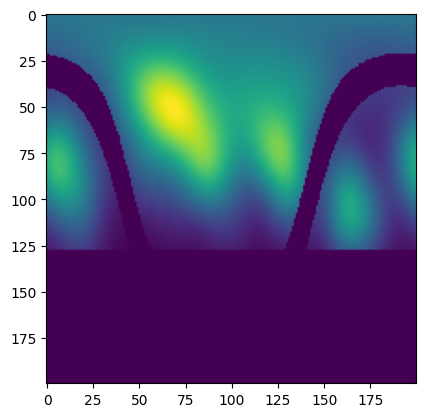

In [10]:
ras = np.linspace(0, 2*np.pi, 200)
decs = np.linspace(-np.pi/2., np.pi/2., 200)

bkg_probs = np.flip(np.array([acflares_obj.bkg_spatial_pdf(ras, dec) for dec in decs]))

plt.imshow(bkg_probs)

In [11]:
import healpy as hp
cotheta, phi = hp.pix2ang(1024, np.arange(hp.nside2npix(1024)))
theta = np.pi / 2. - cotheta
np.sum(acflares_obj.bkg_spatial_pdf(phi, theta))

np.float64(1.0)

In [12]:
t0 = time.time()
npix = hp.nside2npix(1024)
t1 = time.time()
pix = np.arange(npix)
t2 = time.time()
hp.pix2ang(1024, pix)
t3 = time.time()

t1-t0, t2-t1, t3-t2

(7.414817810058594e-05, 0.025934219360351562, 0.3544020652770996)

In [13]:
cat = acflares_obj.scramble()
cat["bkg_pdf"].to_numpy()

array([8.14649217e-08, 3.14738955e-07, 1.61736674e-07, 9.97768328e-08,
       1.25600860e-07, 1.56854261e-07, 8.47499599e-08, 3.11849879e-07,
       4.86108512e-08, 2.08182204e-07, 3.72825295e-08, 6.80774846e-08,
       2.32789028e-07, 1.47219484e-07, 1.25934240e-07, 1.87391695e-07,
       1.23944249e-07, 2.61868853e-07, 6.23888775e-08, 1.94330321e-07,
       9.30500329e-08, 1.26401092e-07, 1.21950669e-07, 5.40113035e-08,
       2.25830778e-07, 8.56718569e-08, 1.73889843e-07, 6.90748303e-08,
       3.01780959e-07, 2.39856079e-07, 1.78269417e-07, 2.23648620e-07,
       1.72636746e-07, 1.14724394e-07, 7.58372426e-08, 1.28633312e-07,
       9.88796386e-08, 1.27781662e-07, 1.94991764e-07, 1.18138702e-07,
       2.20263957e-07, 8.68729644e-08, 1.60374617e-07, 1.47289270e-07,
       1.82962655e-07, 1.88191329e-07, 2.12578241e-07, 2.93912051e-07,
       2.40318001e-07, 1.87527211e-07, 1.63343756e-07, 1.93715573e-07,
       1.71417814e-07, 1.90528725e-07, 2.26858652e-07, 6.74238721e-08,
      

In [14]:
cat = acflares_obj.scramble()
acflares_obj.set_bkg_pdf_per_source(cat)

In [15]:
prob_3s = 1.35e-3
prob_5s = 2.87e-7
1/prob_3s

740.7407407407406

In [16]:
acflares.at[3, "t-peak"] = 5

In [17]:
nutimes = np.array([nu.time_mjd for nu in nus.data])

In [18]:
minflarestime, maxflarestime = (
    np.min(acflares["t-peak"]), np.max(acflares["t-peak"]) + 365.
)

In [19]:
weights = np.array(weights)
nutimes = np.array(nutimes)
sumweight = np.array([np.sum(weights[i]) for i in range(len(weights))])
len(sumweight[sumweight != 0.])

77

In [20]:
np.min(nutimes), np.max(nutimes)

(np.float64(55695.064151089224), np.float64(60677.575022281475))

In [21]:
timemask = (nutimes >= minflarestime) & (nutimes <= maxflarestime)
len(nutimes[timemask])

269

63


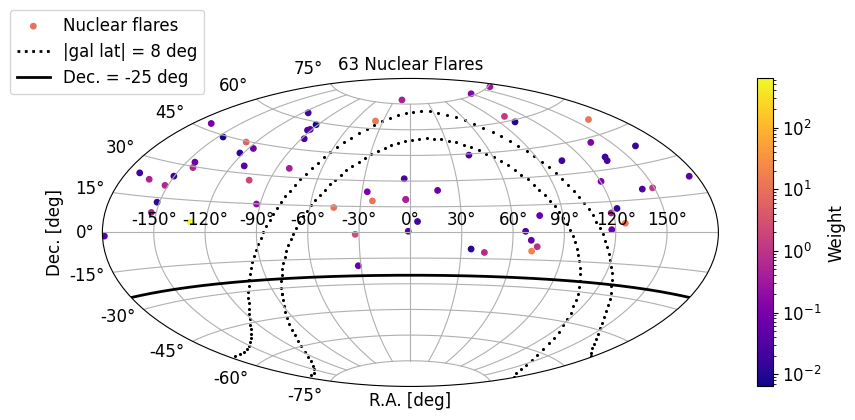

In [22]:
acflares_obj = AccretionFlaresSjoertCatalogue()
weighter = StrengthFluxWeightHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
print(len(acflares["ra_deg"]))
plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
    c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    norm="log",
    cmap="plasma"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-25.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -25 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Weight", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("../data/sjoert_accr_flares_data", dpi=150, bbox_inches="tight")

Text(0, 0.5, 'Dec. [deg]')

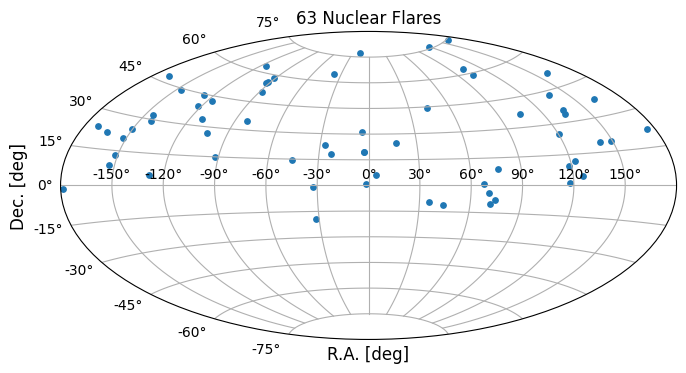

In [23]:
from mhealpy import HealpixMap
import healpy as hp

acflares_obj = AccretionFlaresSjoertCatalogue()
acflares = acflares_obj.parse_data()

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
)

plt.grid()

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

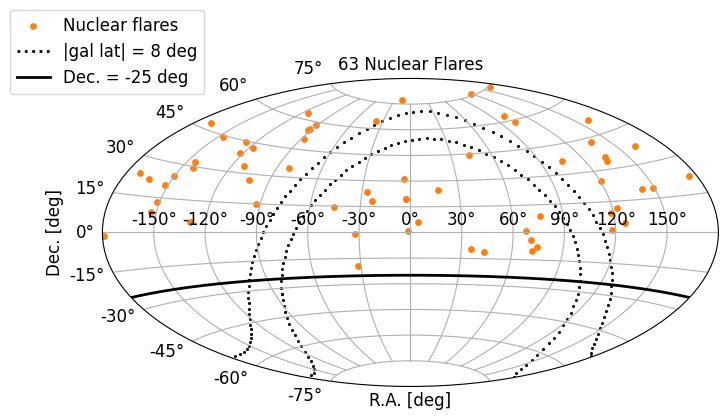

In [72]:
acflares_obj = AccretionFlaresSjoertCatalogue()
weighter = StrengthFluxWeightHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-25.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -25 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("sjoert_sources", dpi=150, bbox_inches="tight")

Found 528 sources in total
Found 528 sources in total


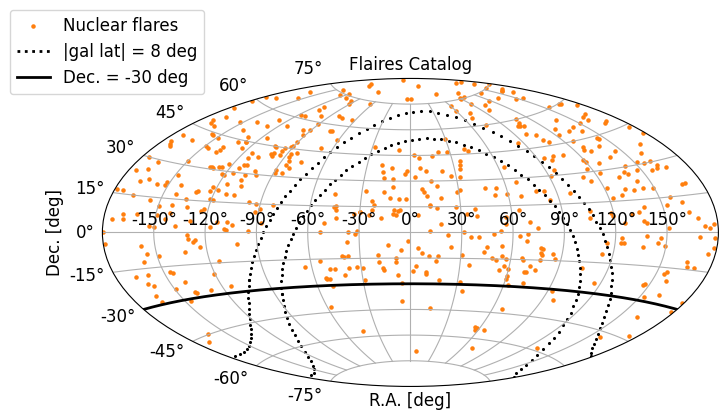

In [40]:
acflares_obj = FlairesCatalogue()
weighter = FluencebolHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=5,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-30.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -30 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Flaires Catalog")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("flaires_sources", dpi=150, bbox_inches="tight")

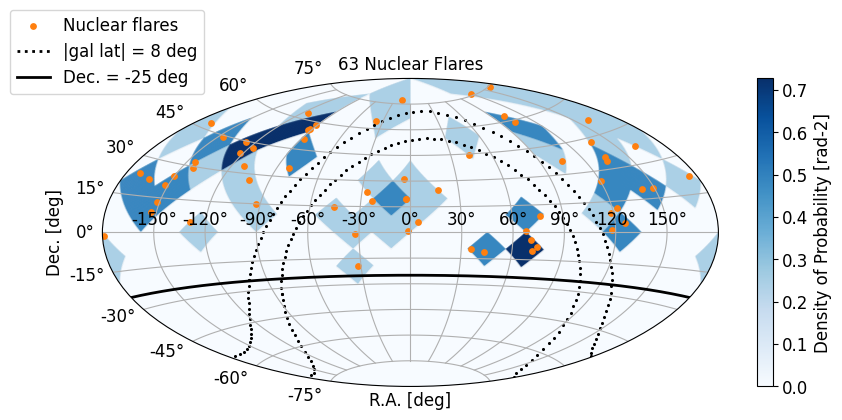

In [94]:
theta = np.pi/2. - acflares["dec_deg"].to_numpy()*np.pi/180.
phi = acflares["ra_deg"].to_numpy()*np.pi/180.

nside = 4
hd_nside = 256
bins_per_source = hp.ang2pix(nside, theta, phi)
bins = np.arange(hp.nside2npix(nside)+1)
counts_per_bin, _ = np.histogram(bins_per_source, bins=bins)
bins_probs = counts_per_bin/np.sum(counts_per_bin)
bins_probs = bins_probs / hp.nside2pixarea(nside)

bins_probs = hp.ud_grade(bins_probs, hd_nside)
bins_cothetas, bins_phis = hp.pix2ang(hd_nside, np.arange(hp.nside2npix(hd_nside)))
bins_thetas = np.pi / 2. - bins_cothetas

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(phis_mollweide, bins_thetas, c=bins_probs, cmap="Blues", s=0.01)


acflares_obj = AccretionFlaresSjoertCatalogue()
weighter = StrengthFluxWeightHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-25.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -25 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("sjoert_binning", dpi=150, bbox_inches="tight")

Found 528 sources in total
Found 528 sources in total


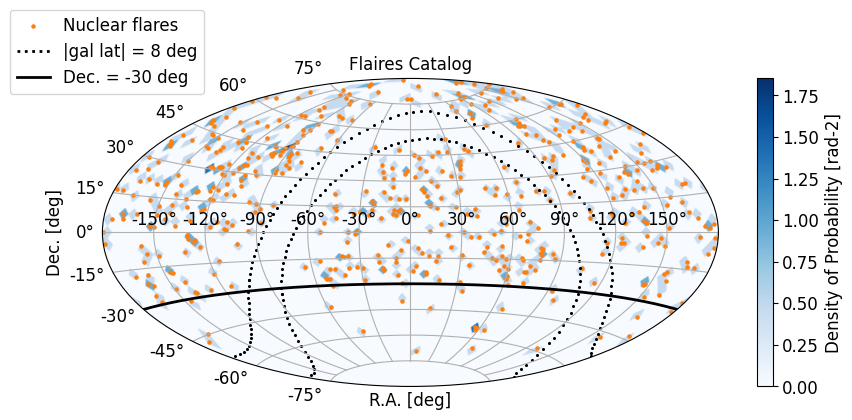

In [28]:
acflares_obj = FlairesCatalogue()
weighter = FluencebolHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()

theta = np.pi/2. - acflares["dec_deg"].to_numpy()*np.pi/180.
phi = acflares["ra_deg"].to_numpy()*np.pi/180.

nside = 16
hd_nside = 256
bins_per_source = hp.ang2pix(nside, theta, phi)
bins = np.arange(hp.nside2npix(nside)+1)
counts_per_bin, _ = np.histogram(bins_per_source, bins=bins)
bins_probs = counts_per_bin/np.sum(counts_per_bin)
bins_probs = bins_probs / hp.nside2pixarea(nside)

bins_probs = hp.ud_grade(bins_probs, hd_nside)
bins_cothetas, bins_phis = hp.pix2ang(hd_nside, np.arange(hp.nside2npix(hd_nside)))
bins_thetas = np.pi / 2. - bins_cothetas

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(phis_mollweide, bins_thetas, c=bins_probs, cmap="Blues", s=0.01)

plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=5,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-30.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -30 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Flaires Catalog")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("flaires_binning", dpi=150, bbox_inches="tight")

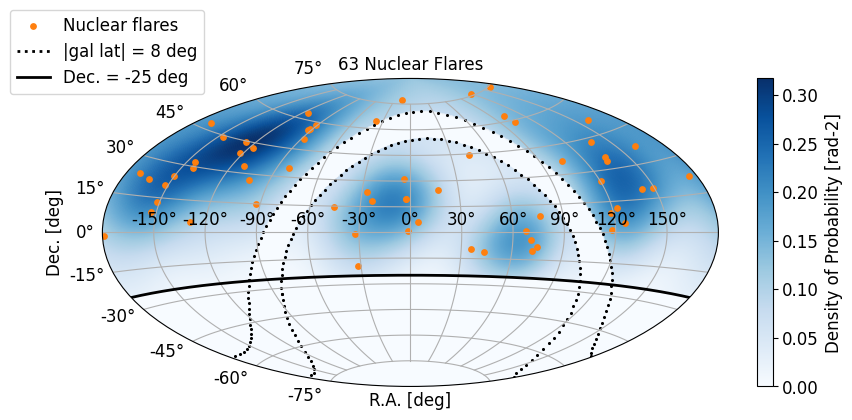

In [95]:
theta = np.pi/2. - acflares["dec_deg"].to_numpy()*np.pi/180.
phi = acflares["ra_deg"].to_numpy()*np.pi/180.

nside = 128
hd_nside = 256

bins_probs = hp.ud_grade(acflares_obj.bkg_distribution, hd_nside)
bins_probs = bins_probs / hp.nside2pixarea(nside)
bins_cothetas, bins_phis = hp.pix2ang(hd_nside, np.arange(hp.nside2npix(hd_nside)))
bins_thetas = np.pi / 2. - bins_cothetas

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(phis_mollweide, bins_thetas, c=bins_probs, cmap="Blues", s=0.01)


acflares_obj = AccretionFlaresSjoertCatalogue()
weighter = StrengthFluxWeightHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-25.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -25 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("sjoert_bkg_distr", dpi=150, bbox_inches="tight")

Found 528 sources in total
Found 528 sources in total


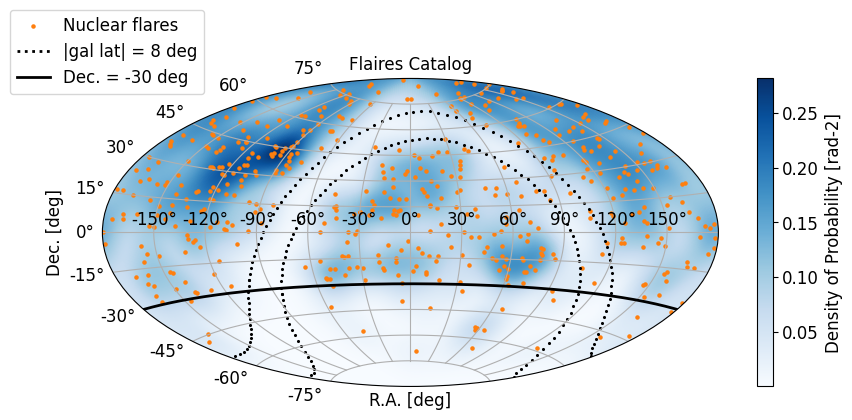

In [35]:
acflares_obj = FlairesCatalogue()
weighter = FluencebolHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()

bins_probs = hp.ud_grade(acflares_obj.bkg_distribution, hd_nside)
bins_probs = bins_probs / hp.nside2pixarea(128)
bins_cothetas, bins_phis = hp.pix2ang(hd_nside, np.arange(hp.nside2npix(hd_nside)))
bins_thetas = np.pi / 2. - bins_cothetas

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(phis_mollweide, bins_thetas, c=bins_probs, cmap="Blues", s=0.01)

plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=5,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-30.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -30 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Flaires Catalog")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("flaires_bkg_distr", dpi=150, bbox_inches="tight")

In [34]:
hp.npix2nside(len(acflares_obj.bkg_distribution))

128

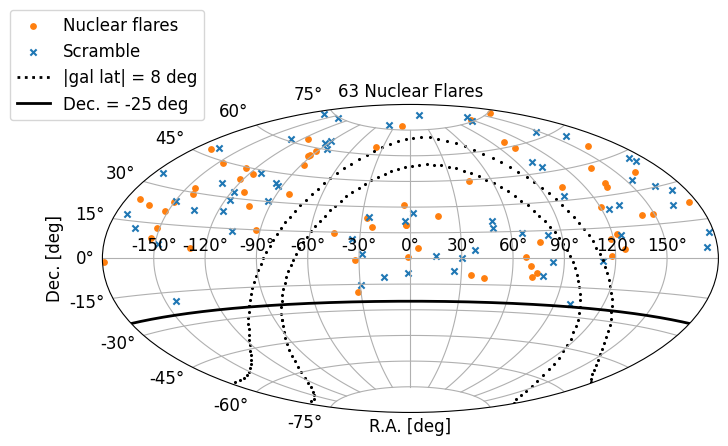

In [90]:
scramble = acflares_obj.scramble()
bins_thetas = scramble["dec_rad"]
bins_phis = scramble["ra_rad"]

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')


acflares_obj = AccretionFlaresSjoertCatalogue()
weighter = StrengthFluxWeightHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

im = plt.scatter(
    phis_mollweide,
    bins_thetas,
    c="tab:blue",
    s=20,
    label="Scramble",
    marker="x"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-25.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -25 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("sjoert_scramble_3", dpi=150, bbox_inches="tight")

Found 528 sources in total
Found 528 sources in total


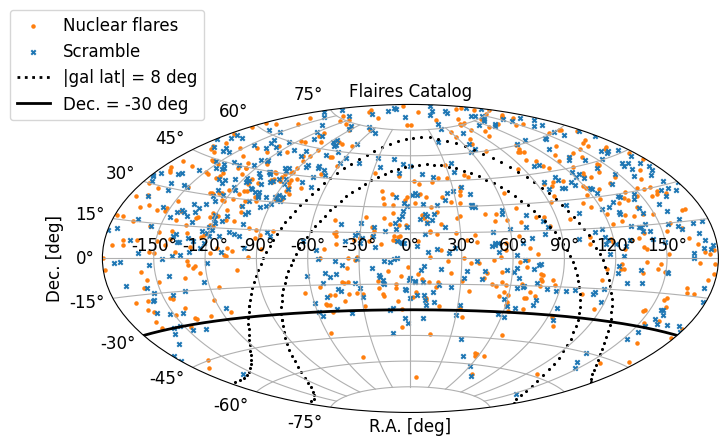

In [39]:
acflares_obj = FlairesCatalogue()
weighter = FluencebolHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

scramble = acflares_obj.scramble()
bins_thetas = scramble["dec_rad"]
bins_phis = scramble["ra_rad"]
phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=5,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

im = plt.scatter(
    phis_mollweide,
    bins_thetas,
    c="tab:blue",
    s=10,
    label="Scramble",
    marker="x"
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-30.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -30 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Flaires Catalog")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("flaires_scramble_3", dpi=150, bbox_inches="tight")

In [22]:
mymap = acflares_obj.generate_bkg_distribution_allsky(acflares_obj.data, 4, 128)

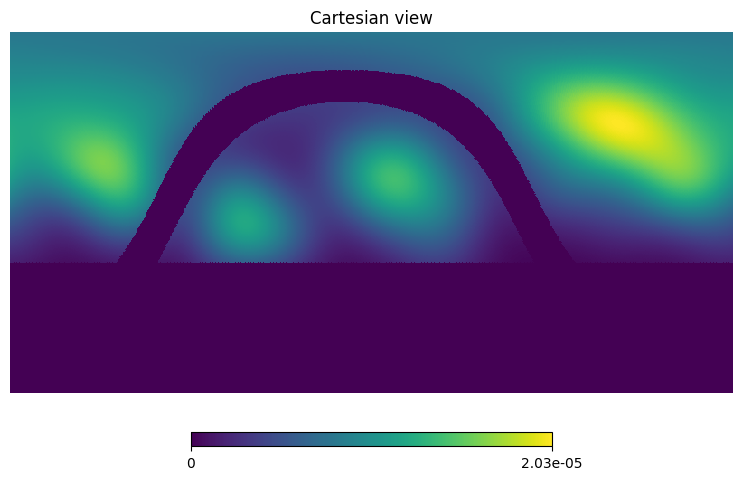

In [23]:
hp.cartview(
    acflares_obj.bkg_distribution
)

Found 528 sources in total


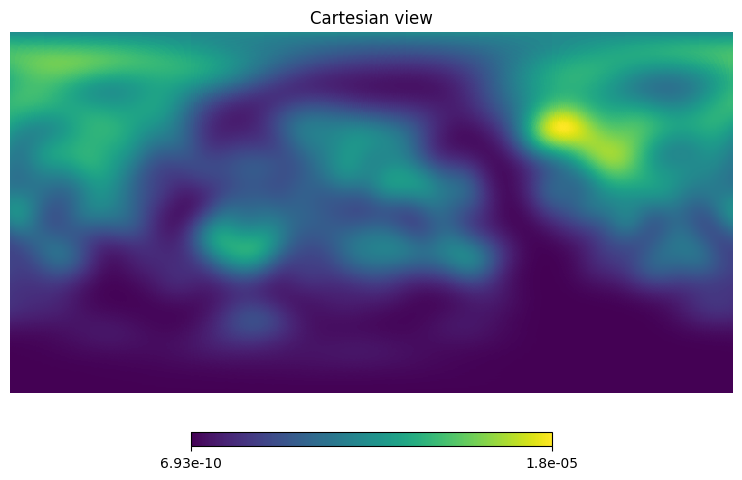

In [24]:
acflares_obj = FlairesCatalogue()
hp.cartview(
    acflares_obj.bkg_distribution
)

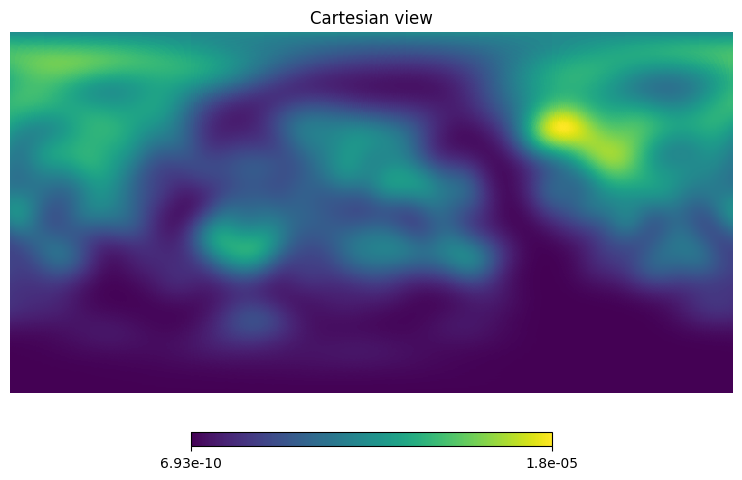

In [25]:
hp.cartview(
    acflares_obj.generate_bkg_distribution_allsky(
        acflares_obj.data, nside=16, hd_nside=128, sigma_smoothing=8.
    ),
    acflares_obj.min_declination,
    acflares_obj.gp_threshold
)

Text(0, 0.5, 'Dec. [deg]')

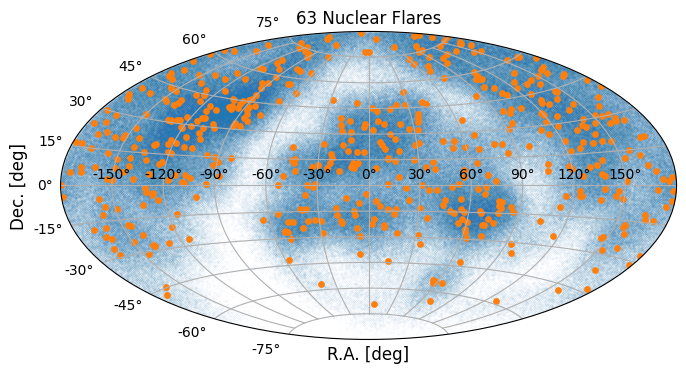

In [26]:
selected_phi, selected_theta = acflares_obj.select_random_dirs(size=1000000)

"""
total_mask = get_mask(selected_phi, selected_theta)
while np.sum(total_mask) > 0.:
    new_phi, new_theta = select_random_dirs(size=np.sum(total_mask))
    selected_phi[total_mask] = new_phi
    selected_theta[total_mask] = new_theta
    total_mask = get_mask(selected_phi, selected_theta)
"""

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')
ras_mollweide_new = np.empty(len(selected_phi))
ras_mollweide_new[selected_phi<=np.pi] = selected_phi[selected_phi<=np.pi]
ras_mollweide_new[selected_phi>np.pi] = selected_phi[selected_phi>np.pi] - 2*np.pi

acflares = acflares_obj.data
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

im = plt.scatter(
    ras_mollweide_new,
    selected_theta,
    s=0.0002,
    #s=15,
    label="Nuclear flares",
)

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
)

plt.grid()

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

Text(0, 0.5, 'Dec. [deg]')

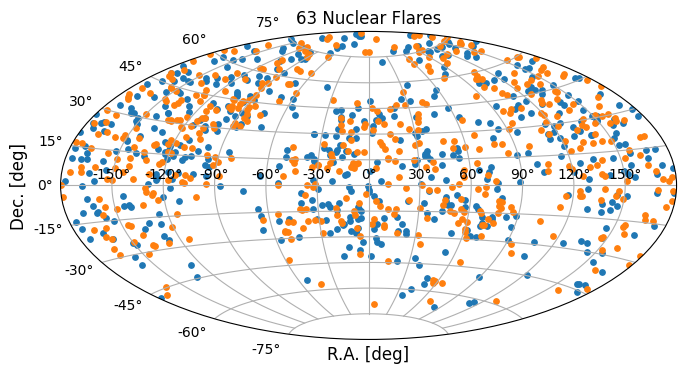

In [27]:
newcat = acflares_obj.scramble()

selected_phi = newcat["ra_deg"]
selected_theta = newcat["dec_deg"]

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')
ras_mollweide_new = np.empty(len(selected_phi))
ras_mollweide_new[selected_phi<=180.] = selected_phi[selected_phi<=180.]
ras_mollweide_new[selected_phi>180.] = selected_phi[selected_phi>180.] - 360.

im = plt.scatter(
    ras_mollweide_new*np.pi/180.,
    selected_theta*np.pi/180.,
    #s=0.0002,
    s=15,
    label="Nuclear flares",
)

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
)

plt.grid()

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

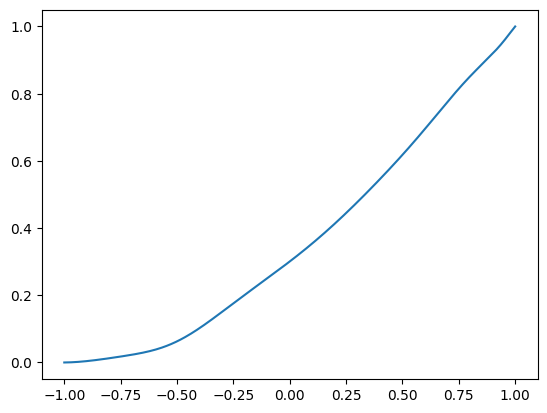

In [28]:
bkg = acflares_obj.bkg_distribution
#bkg = hp.ud_grade(bkg, 256)
#bkg = bkg / np.sum(bkg)
npix = len(bkg)
nside = hp.npix2nside(npix)
colats, lons = hp.pix2ang(nside, np.arange(npix))
lats = np.pi / 2. - colats
possible_lats = np.sort(np.array(list(set(lats))))
possible_lons = np.sort(np.array(list(set(lons))))
prob_per_lat = np.array(
    [np.sum(bkg[lats==lat]) for lat in possible_lats]
)
prob_per_lon = np.array(
    [np.sum(bkg[lons==lon]) for lon in possible_lons]
)
#plt.plot(np.sin(possible_la
#plt.plot(np.sin(possible_lats), prob_per_lat)
plt.plot(np.sin(possible_lats), np.cumsum(prob_per_lat))

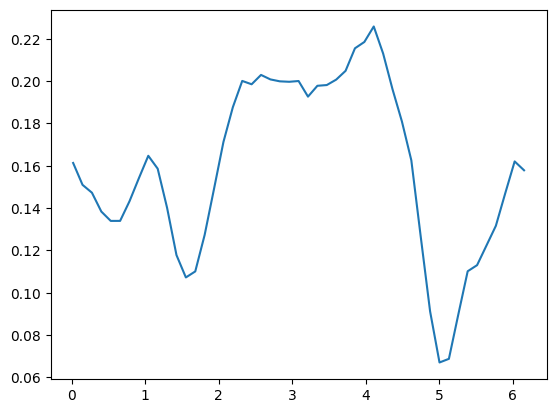

In [29]:
def plot_probabilty_lon(possible_lons, prob_per_lon, n_samples):
    plot_lons = np.linspace(1/n_samples, 2*np.pi, n_samples)
    cumlon = np.cumsum(prob_per_lon)
    plot_cumprobs = np.array([cumlon[np.sum(possible_lons<lon)-1] for lon in plot_lons])
    plot_probs = np.array(
        [(plot_cumprobs[i+1] - plot_cumprobs[i])/(plot_lons[i+1] - plot_lons[i]) for i in range(
        #[(plot_cumprobs[i+1] - plot_cumprobs[i]) for i in range(
            len(plot_cumprobs)-1
        )]
    )
    plt.plot(plot_lons[:-1], plot_probs)

def plot_probabilty_lat(possible_lats, prob_per_lat, n_samples):
    plot_lats = np.linspace(-1, 1, n_samples)
    cumlat = np.cumsum(prob_per_lat)
    plot_cumprobs = np.array([cumlat[np.sum(np.sin(possible_lats)<lat)-1] for lat in plot_lats[1:]])
    plot_probs = np.array(
        [(plot_cumprobs[i+1] - plot_cumprobs[i])/(plot_lats[i+1] - plot_lats[i]) for i in range(
        #[(plot_cumprobs[i+1] - plot_cumprobs[i]) for i in range(
            len(plot_cumprobs)-1
        )]
    )
    plt.plot(plot_lats[1:-1], plot_probs)


plot_probabilty_lon(possible_lons, prob_per_lon, 50)

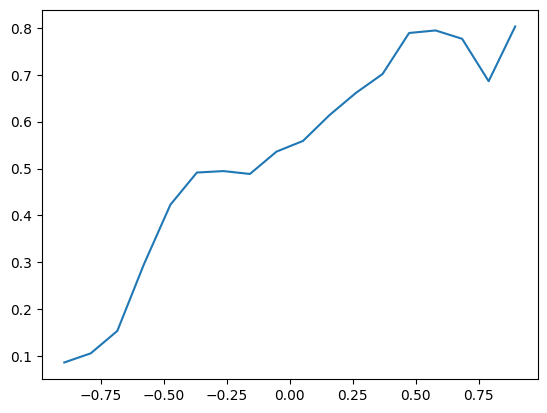

In [30]:
plot_probabilty_lat(possible_lats, prob_per_lat, 20)


In [32]:
possible_lons, prob_per_lon

(array([0.00000000e+00, 6.13592315e-03, 6.18423751e-03, ...,
        6.27695199e+00, 6.27700107e+00, 6.27704938e+00]),
 array([8.49607620e-04, 8.52619321e-04, 9.46893331e-06, ...,
        9.20605520e-06, 9.41099799e-06, 8.56181432e-04]))

In [33]:
prob_per_lon

array([8.49607620e-04, 8.52619321e-04, 9.46893331e-06, ...,
       9.20605520e-06, 9.41099799e-06, 8.56181432e-04])

In [34]:
decs = acflares['dec_rad'].to_numpy()
np.array([possible_lats[np.sum(possible_lats < dec) - 1] for dec in np.sort(decs)])

array([-1.20516696, -1.14008996, -1.02834407, -0.98850559, -0.9684979 ,
       -0.96181493, -0.94842784, -0.94172351, -0.82654563, -0.82654563,
       -0.78529135, -0.77146223, -0.7575926 , -0.74368143, -0.73670993,
       -0.69531195, -0.63571129, -0.61642887, -0.59112041, -0.54782685,
       -0.54173694, -0.53566926, -0.53566926, -0.52359878, -0.51161184,
       -0.50564863, -0.49970504, -0.49970504, -0.48787515, -0.48198807,
       -0.48198807, -0.48198807, -0.48198807, -0.48198807, -0.48198807,
       -0.47026777, -0.46443382, -0.46443382, -0.45861688, -0.45861688,
       -0.45281659, -0.45281659, -0.44126467, -0.43551237, -0.43551237,
       -0.42977543, -0.42977543, -0.42405354, -0.41265368, -0.40697513,
       -0.40131044, -0.40131044, -0.39565933, -0.39002154, -0.38439677,
       -0.37878478, -0.37878478, -0.3731853 , -0.3731853 , -0.36759806,
       -0.36759806, -0.36202282, -0.36202282, -0.36202282, -0.36202282,
       -0.36202282, -0.35645933, -0.35090734, -0.35090734, -0.34

In [45]:
def mykstest_lats(decs, bkg, min_dec):

    min_dec = min_dec * np.pi / 180.
    
    npix = len(bkg)
    nside = hp.npix2nside(npix)
    colats, lons = hp.pix2ang(nside, np.arange(npix))
    lats = np.pi / 2. - colats
    possible_lats = np.sort(np.array(list(set(lats))))
    prob_per_lat = np.cumsum(np.array(
        [np.sum(bkg[lats==lat]) for lat in possible_lats]
    ))
    s = np.linspace(1/len(decs), 1, len(decs))
    cumul_data = np.array(
        [prob_per_lat[np.sum(
            possible_lats < dec
        ) - 1] for dec in np.sort(decs)]
    )
    decs = np.sort(decs)
    cumul_data_uniform = (np.sin(decs) - np.sin(min_dec)) / (1 - np.sin(min_dec))
    #print(s, cumul_data , s-cumul_data)
    diffs = np.abs(s-cumul_data)
    diffs_uniform = np.abs(s-cumul_data_uniform)
    ts = np.max(diffs)
    ts_uniform = np.max(diffs_uniform)
    pval = distributions.ksone.sf(ts, len(decs))
    pval_uniform = distributions.ksone.sf(ts_uniform, len(decs))
    print(f"ts: {ts}, ts_uniform: {ts_uniform}")
    print(f"pval: {pval}, pval_uniform: {pval_uniform}")
    return pval, pval_uniform

def mykstest_lons(ras, bkg):
    
    npix = len(bkg)
    nside = hp.npix2nside(npix)
    colats, lons = hp.pix2ang(nside, np.arange(npix))
    possible_lons = np.sort(np.array(list(set(lons))))
    prob_per_lon = np.cumsum(np.array(
        [np.sum(bkg[lons==lon]) for lon in possible_lons]
    ))
    s = np.linspace(1/len(ras), 1, len(ras))
    cumul_data = np.array(
        [prob_per_lon[np.sum(
            possible_lons < ra
        ) - 1] for ra in np.sort(ras)]
    )
    ras = np.sort(ras)
    cumul_data_uniform = ras / ( 2 * np.pi )
    diffs = np.abs(s-cumul_data)
    diffs_uniform = np.abs(s-cumul_data_uniform)
    ts = np.max(diffs)
    ts_uniform = np.max(diffs_uniform)
    pval = distributions.ksone.sf(ts, len(ras))
    pval_uniform = distributions.ksone.sf(ts_uniform, len(ras))
    print(f"ts: {ts}, ts_uniform: {ts_uniform}")
    print(f"pval: {pval}, pval_uniform: {pval_uniform}")
    return pval, pval_uniform

In [46]:
acflares_obj = FlairesCatalogue()
acflares = acflares_obj.data
mykstest_lats(acflares['dec_rad'].to_numpy(), acflares_obj.bkg_distribution, -30)
mykstest_lons(acflares['ra_rad'].to_numpy(), acflares_obj.bkg_distribution)

Found 528 sources in total
ts: 0.018954049511754216, ts_uniform: 0.2910616967719979
pval: 0.6757856815203828, pval_uniform: 2.0495333403313274e-40
ts: 0.014383417628896167, ts_uniform: 0.07888428030303041
pval: 0.7961454196336619, pval_uniform: 0.001319864716162956


(np.float64(0.7961454196336619), np.float64(0.001319864716162956))

In [47]:
acflares_obj = AccretionFlaresSjoertCatalogue()
acflares = acflares_obj.data
mykstest_lats(acflares['dec_rad'].to_numpy(), acflares_obj.bkg_distribution, -25)
mykstest_lons(acflares['ra_rad'].to_numpy(), acflares_obj.bkg_distribution)

ts: 0.06086012312420103, ts_uniform: 0.16918502817913042
pval: 0.6029181671866966, pval_uniform: 0.023979884735128475
ts: 0.05310972843676076, ts_uniform: 0.10962887567460314
pval: 0.6772400800645243, pval_uniform: 0.20469222791661412


(np.float64(0.6772400800645243), np.float64(0.20469222791661412))

ValueError: x and y must be the same size

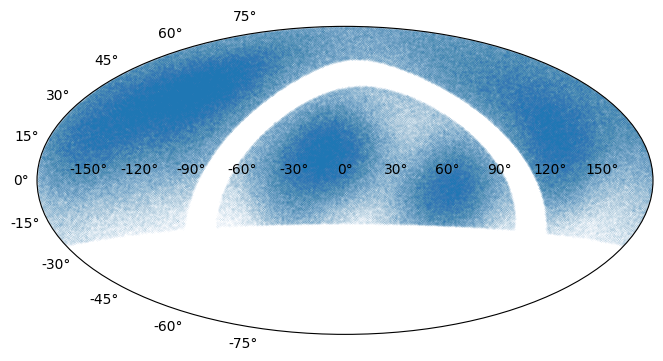

In [38]:
nside=4
sigma_smoothing = 15.  # in degrees
hd_nside = 128
min_theta = -25.
max_gal_lat = 8.

def generate_bkg_distribution_allsky(
    catalog, nside, sigma_smoothing=15.
):
    """
    Given the coordinates of the sources, it returns an all-sky
    probability map.

    :param catalog: catalog with info regarding coordinates
    :param nside: nside for healpix histogramming of sources
    :param sigma_smoothing [deg]: smoothing to apply to the 
    healpix histogram
    :return: the healpix map with the probabilities
    """

    theta = np.pi/2. - catalog["dec_deg"].to_numpy()*np.pi/180.
    phi = catalog["ra_deg"].to_numpy()*np.pi/180.
    
    bins_per_source = hp.ang2pix(nside, theta, phi)
    bins = np.arange(hp.nside2npix(nside)+1)
    counts_per_bin, _ = np.histogram(bins_per_source, bins=bins)
    bins_probs = counts_per_bin/np.sum(counts_per_bin)
    bins_probs = hp.ud_grade(bins_probs, hd_nside)
    bins_probs = bins_probs / np.sum(bins_probs)
    bins_probs = hp.sphtfunc.smoothing(
        bins_probs, sigma=sigma_smoothing*np.pi/180.
    )
    bins_probs[bins_probs<0.] = 0.
    bins_probs = bins_probs / np.sum(bins_probs)
    return bins_probs

def apply_cuts_on_bkg_distribution(
    bins_probs, hd_nside=64, min_theta=-25, max_gal_lat=8.
):
    """
    Upgrades the map resolution and applies the necessary cuts.

    :param bins_probs: the initial healpix map (an array)
    :param hd_nside: up to which nside the map must be upgraded
    :param min_theta [deg]: lower cut on declination
    :param max_gal_lat [deg]: exclude the galactic plane up to this
    latitude
    :return: upgraded map with cuts applied
    """

    hd_map = bins_probs
    #hd_map = hp.ud_grade(bins_probs, hd_nside)
    #hd_map = hd_map / np.sum(hd_map)
    hd_cothetas, hd_phis = hp.pix2ang(
        hd_nside, np.arange(hp.nside2npix(hd_nside))
    )
    hd_thetas = np.pi/2. - hd_cothetas
    low_theta_mask = hd_thetas < min_theta * np.pi / 180.
    hd_icrs = SkyCoord(
        ra=hd_phis*u.rad,
        dec=hd_thetas*u.rad,
        frame='icrs',
        unit='rad',
    )
    hd_bs = hd_icrs.galactic.b.deg
    galactic_mask = np.abs(hd_bs) < 8.
    
    hd_map[low_theta_mask | galactic_mask] = 0.
    hd_map = hd_map / np.sum(hd_map)

    return hd_map

bins_probs = generate_bkg_distribution_allsky(
    acflares, nside, sigma_smoothing=sigma_smoothing
)
bins_probs = apply_cuts_on_bkg_distribution(
    bins_probs, hd_nside, min_theta=min_theta, max_gal_lat=max_gal_lat
)

def select_random_dirs(size):

    npix = len(bins_probs)
    nside = hp.npix2nside(npix)
    selected_bins = np.random.choice(
        a=np.arange(npix),
        p=bins_probs,
        size=size
    )
    
    ipix = hp.ring2nest(nside, ipix=selected_bins)
    #ipix=selected_bins
    
    n_order = hp.nside2order(nside)
    n_up = 29 - n_order
    i_up = ipix * 4 ** n_up
    i_up += np.random.randint(0, 4 ** n_up, size=np.size(ipix))
    
    selected_cotheta, selected_phi = hp.pix2ang(
        nside=2 ** 29, ipix=i_up, nest=True
    )
    selected_theta = (np.pi/2. - selected_cotheta) * 180. / np.pi
    selected_phi = selected_phi * 180. / np.pi
    
    return selected_phi, selected_theta

"""
def get_mask(phi, theta):
    min_theta = -25.
    low_theta_mask = theta < min_theta
    icrs = SkyCoord(
        ra=phi*u.deg,
        dec=theta*u.deg,
        frame='icrs',
        unit='deg',
    )
    bs = icrs.galactic.b.deg
    galactic_mask = np.abs(bs) < 8.
    total_mask = (low_theta_mask) | (galactic_mask)
    return total_mask
"""

selected_phi, selected_theta = select_random_dirs(size=1000000)
"""
total_mask = get_mask(selected_phi, selected_theta)
while np.sum(total_mask) > 0.:
    new_phi, new_theta = select_random_dirs(size=np.sum(total_mask))
    selected_phi[total_mask] = new_phi
    selected_theta[total_mask] = new_theta
    total_mask = get_mask(selected_phi, selected_theta)
"""

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')
ras_mollweide_new = np.empty(len(selected_phi))
ras_mollweide_new[selected_phi<=180.] = selected_phi[selected_phi<=180.]
ras_mollweide_new[selected_phi>180.] = selected_phi[selected_phi>180.] - 360.

im = plt.scatter(
    ras_mollweide_new*np.pi/180.,
    selected_theta*np.pi/180.,
    s=0.0002,
    #s=15,
    label="Nuclear flares",
)

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
)

plt.grid()

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

ValueError: x and y must be the same size

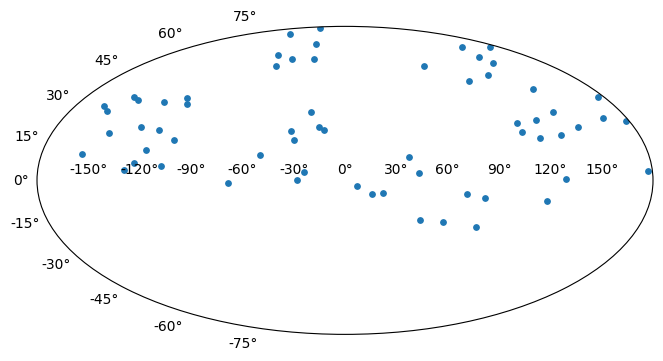

In [39]:
selected_phi, selected_theta = select_random_dirs(size=len(acflares))

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')
ras_mollweide_new = np.empty(len(selected_phi))
ras_mollweide_new[selected_phi<=180.] = selected_phi[selected_phi<=180.]
ras_mollweide_new[selected_phi>180.] = selected_phi[selected_phi>180.] - 360.

im = plt.scatter(
    ras_mollweide_new*np.pi/180.,
    selected_theta*np.pi/180.,
    #s=0.0002,
    s=15,
    label="Nuclear flares",
)

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="Nuclear flares",
)

plt.grid()

plt.title("63 Nuclear Flares")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

In [40]:
180./8. 

22.5

In [41]:
icrs = SkyCoord(
    ra=acflares["ra_deg"]*u.deg,
    dec=acflares["dec_deg"]*u.deg,
    frame='icrs',
    unit='deg',
)
bs = icrs.galactic.b.deg
np.abs(bs) < 8.

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False])

In [42]:
colat, lon = hp.pix2ang(nside, selected_bins[0])
lat = (np.pi/2. - colat) * 180. / np.pi
lon = lon * 180. / np.pi
lon, lat

NameError: name 'selected_bins' is not defined

In [105]:
hp.boundaries(nside, 1)

array([[ 0.00000000e+00,  4.56398915e-17, -7.07106781e-01,
        -7.45355992e-01],
       [ 0.00000000e+00,  7.45355992e-01,  7.07106781e-01,
         9.12797830e-17],
       [ 1.00000000e+00,  6.66666667e-01,  0.00000000e+00,
         6.66666667e-01]])

In [84]:
density_map.data, density_map.uniq

(array([1, 2, 3, 3, 6, 1, 3, 7, 3, 6, 8, 8, 6, 3, 2, 0, 0, 1]),
 array([ 4, 23, 22, 21, 20, 27, 26, 25, 24,  7,  8,  9, 10, 11, 12, 13, 14,
        15]))

63


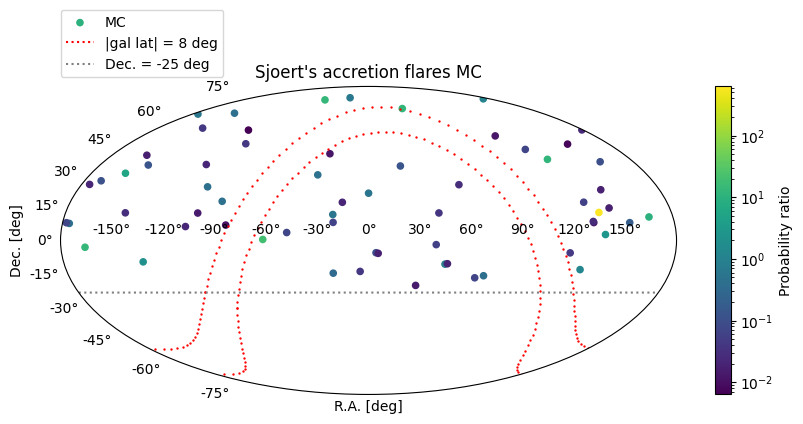

In [43]:
acflares_obj = AccretionFlaresSjoertCatalogue()
acflares = acflares_obj.parse_data()
acflares = acflares_obj.scramble()
print(len(acflares["ra_deg"]))
plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='mollweide')
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.
echo_fluxes = np.array([float(flux.split("±")[0]) for flux in acflares['ΔFIR']])

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=20,
    label="MC",
    c=weighter.weight_catalogue(acflares, 0., ignore_times=True),
    norm="log",
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="red", linestyle="dotted", label="|gal lat| = 8 deg")
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=0.5, c="r")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=0.5, c="r")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-25.*np.pi/180.)
plt.plot(ras_bord, des_bord, linestyle = "dotted", color="grey", label="Dec. = -25 deg")
plt.legend(loc=(0, 1.03))
plt.gcf().colorbar(
    im,
    label="Probability ratio",
)

plt.title("Sjoert's accretion flares MC")
plt.xlabel("R.A. [deg]")
plt.ylabel("Dec. [deg]")
plt.savefig("../data/sjoert_accr_flares_MC", dpi=150, bbox_inches="tight")

In [44]:
np.log10(acflares['ΔFIR/Frms']*echo_fluxes)

0     2.163388
1     1.444544
2     2.242395
3     1.525796
4     0.345178
        ...   
58    1.042379
59   -0.242604
60    1.137607
61    0.558709
62    0.840733
Name: ΔFIR/Frms, Length: 63, dtype: float64

In [45]:
acflares['ΔFIR/Frms']*np.array([float(flux.split("±")[0]) for flux in acflares['ΔFIR']])

0     145.676
1      27.832
2     174.741
3      33.558
4       2.214
       ...   
58     11.025
59      0.572
60     13.728
61      3.620
62      6.930
Name: ΔFIR/Frms, Length: 63, dtype: float64

In [46]:
acflares.keys()

Index(['Source_Name', 'ra_rad', 'dec_rad', 'ra_deg', 'dec_deg', 't-peak',
       'weight', 'Riseb', 'Fadeb', 'ΔFIR/Frms', 'ΔFIR', 'z', 'MBH', 'PAGN',
       'Spectro.'],
      dtype='object')

In [47]:
possible_tdes = ['TDE', 'TDE?']
tdemask = np.logical_and(
    [echotype in possible_tdes for echotype in acflares["Spectro."]],
    acflares["MBH"] != '–',
)
notdemask = [echotype not in possible_tdes for echotype in acflares["Spectro."]]
knowntdes = ["AT2019dsg", "AT2019aalc"]
knowntdemask = [name not in knowntdes for name in acflares["Name"]]
tdeforpdfmask = np.logical_and(tdemask, knowntdemask)
tdeforpdf = acflares[tdeforpdfmask]
tdeforbkgpdf = acflares[notdemask]
plt.hist(np.log10(tdeforpdf["ΔFIR/Frms"]), bins = 30)
plt.hist(np.log10(tdeforbkgpdf["ΔFIR/Frms"]), bins = 30)
#plt.yscale('log')

KeyError: 'Name'

In [48]:
tdes_df = pd.read_csv(
    "../data/sjoert_catalog.txt",
    sep='\t',
    header=0,
    names=[
        'Name',
        't-peak',
        'Riseb',
        'Fadeb',
        'ΔFIR/Frms',
        'ΔFIR',
        'z',
        'MBH',
        'PAGN',
        'Spectro.',
    ]
)

In [49]:
import astropy.io.ascii

In [50]:
acflares = astropy.io.ascii.read("../data/ZTF_neoWISE_flares_acflares.dat")

In [51]:
acflares.keys()

['qclass',
 'redshift',
 'N_pre',
 'N_post',
 'echo_duration_w1',
 'pre_median_flux_w1',
 'pre_median_e_flux_w1',
 'pre_median_total_flux_w1',
 'pre_rms_flux_w1',
 'post_max_flux_w1',
 'post_mean_flux_w1',
 'post1yr_max_flux_w1',
 'post1yr_mean_flux_w1',
 'post1yr_sum_flux_w1',
 'e_post_max_flux_w1',
 'name',
 'chi2',
 'sigma_rise',
 'sigma_fade',
 'e_sigma_rise',
 'e_sigma_fade',
 'n_rise',
 'n_fade',
 'mean_color',
 'color_slope',
 'e_mean_color',
 'e_color_slope',
 'ra',
 'dec',
 'ndetections',
 'ndetections_negative',
 'ndetections_g',
 'ndetections_r',
 'median_color',
 'offset_rms_r',
 'offset_unc_r',
 'offset_sig_r',
 'offset_med_r',
 'offset_weighted_r',
 'offset_rms_g',
 'offset_unc_g',
 'offset_sig_g',
 'offset_med_g',
 'offset_weighted_g',
 'offset_sig',
 'offset_rms_ps1',
 'offset_med_ps1',
 'offset_sig_ps1',
 'flare_n_pre',
 'flare_n_post',
 'flare_peak_mag',
 'flare_peak_jd',
 'flare_amplitude_mag',
 'flare_duration_day',
 'flare_postpeak_duration_day',
 'flare_prepeak_du

In [52]:
import numpy as np
mjds = np.array(acflares['flare_peak_jd']) - 2400000.5

In [53]:
mjds = np.array([round(d,1) for d in mjds])
mjds

array([58607.5, 58568.4, 58709.5, 58878.1, 58652.3, 58605.2, 58682.2,
       58677.3, 58749.5, 58758.3, 58891.2, 58448.3, 58506.4, 58732.2,
       58867.3, 58475.1, 58717.4, 58534.3, 58646.5, 58750.1, 58717.2,
       58513.5, 58974.2, 58978.3, 58558.4, 58903.2, 58539.4, 58652.2,
       58390.3, 58641.2, 58658.2, 58540.5, 58802.2, 58678.2, 58510.2,
       58556.4, 58363.2, 58637.2, 58628.2, 58851.1, 58791.2, 58867.2,
       58764.3, 58378.2, 58758.1, 58860.3, 58608.2, 58547.2, 58261.4,
       58789.5, 58449.6, 58620.2, 58432.5, 58798.3, 58651.2, 58753.1,
       58449.4, 58713.1, 58811.6, 58717.4, 58582.5, 58733.1, 58672.5])

In [54]:
mjds_tdes = tdes_df['t-peak'].to_numpy()

In [55]:
ras = []
des = []
for index, mjd in enumerate(mjds_tdes):
    if mjd in mjds:
        #print(f"{tdes_df['Name'][index]} Found!")
        mjd_index = np.where(mjds==mjd)[0][0]
        ra = acflares['ra'][mjd_index]
        de = acflares['dec'][mjd_index]
        ras.append(ra)
        des.append(de)
    else:
        print(f"{tdes_df['Name'][index]} not found")
ras = np.array(ras)
des = np.array(des)
tdes_df.insert(1, 'Dec', des)
tdes_df.insert(1, 'RA', ras)
tdes_df

,Name,RA,Dec,t-peak,Riseb,Fadeb,ΔFIR/Frms,ΔFIR,z,MBH,PAGN,Spectro.
0,AT2019dsg,314.262416,14.204515,58620.2,32.1,81.9,92.2,1.58 ± 0.02,0.0512,6.74 (C21),0.000,TDE
1,AT2019fdr,257.278575,26.855758,58672.5,30.8,336.6,39.2,0.71 ± 0.07,0.2666,7.10 (F20),0.000,TDE?
2,AT2019aalc,231.069435,4.855293,58658.2,49.0,167.7,15.7,11.13 ± 0.10,0.0356,7.23 (L19),0.146,TDE?
3,AT2018dyk,233.283396,44.535612,58261.4,60.0,342.0,23.8,1.41 ± 0.03,0.0367,5.50 (F19),0.000,TDE?
4,AT2019aame,215.051850,31.894158,58363.2,–,138.0,12.3,0.18 ± 0.01,–,–,0.540,–
...,...,...,...,...,...,...,...,...,...,...,...,...
58,AT2020iq,43.832167,-11.413455,58878.1,22.7,71.5,24.5,0.45 ± 0.01,0.096,6.37 (V23),0.000,TDE?
59,AT2019xgg,162.284045,37.221261,58891.2,81.6,446.2,4.4,0.13 ± 0.01,–,–,6.003,–
60,AT2020atq,102.323538,62.513401,58903.2,39.3,205.5,20.8,0.66 ± 0.01,–,–,0.003,–
61,AT2021aeuj,137.107215,42.894890,58974.2,79.0,233.5,18.1,0.20 ± 0.01,0.695,–,0.032,–


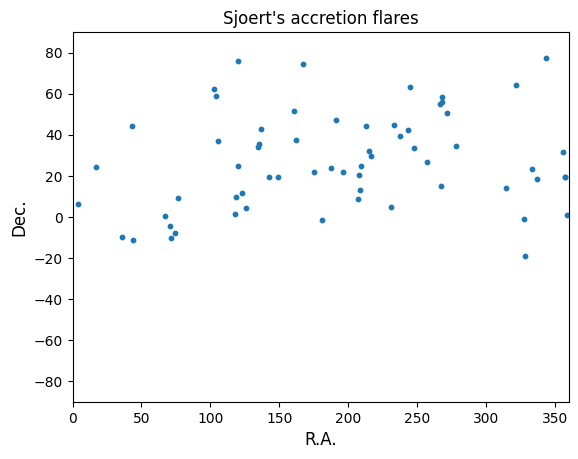

In [56]:
plt.scatter(tdes_df["RA"], tdes_df["Dec"], s=10)
plt.xlim(0,360)
plt.ylim(-90,90)
plt.xlabel("R.A.", fontsize="large")
plt.ylabel("Dec.", fontsize="large")
plt.title("Sjoert's accretion flares", fontsize="large")
plt.savefig("sjoert_catalog_skymap", bbox_inches="tight", dpi=100)

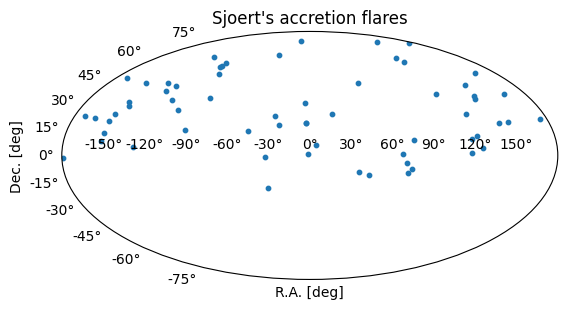

In [57]:
plt.subplot(111, projection='mollweide')
ras_mollweide = np.empty(len(tdes_df))
ras_mollweide[tdes_df["RA"]<=180.] = tdes_df["RA"][tdes_df["RA"]<=180.]
ras_mollweide[tdes_df["RA"]>180.] = tdes_df["RA"][tdes_df["RA"]>180.] - 360.
plt.scatter(
    ras_mollweide*np.pi/180.,
    tdes_df["Dec"]*np.pi/180.,
    s=10,
)
plt.title("Sjoert's accretion flares")
plt.xlabel("R.A. [deg]")
plt.ylabel("Dec. [deg]")
plt.savefig("../data/sjoert_accr_flares", dpi=150, bbox_inches="tight")

In [58]:
min_dec = np.min(tdes_df["Dec"])
width = np.sin(np.abs(min_dec)*np.pi/180.)/4.
offset = np.sin((min_dec)*np.pi/180.)
width, offset, min_dec

(0.08232913618956605, -0.3293165447582642, -19.2272978)

In [59]:
np.sin(np.abs(np.min(tdes_df["Dec"]))*np.pi/180.)/4.

0.08232913618956605

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.25 0.   0.   0.   0.5  0.25 0.25
 0.   0.25 0.5  0.5  0.25 0.25 0.25 0.25 0.75 0.25 0.25 0.5  0.   0.75
 0.75 0.5  1.25 0.25 0.   0.5  0.5  0.75 0.5  0.25 0.5  0.75 0.25 0.25
 0.25 0.5  0.5  0.75 0.   0.25 0.5 ] [-90.         -75.52435158 -69.47314422 -64.7912347  -60.81101756
 -57.27445564 -54.04943238 -51.05755873 -48.2477948  -45.5846914
 -43.04242299 -40.6014665  -38.24661988 -35.96575356 -33.7489886
 -31.58813551 -29.47629938 -27.40759453 -25.37693353 -23.37986812
 -21.41246705 -19.47122063 -17.5529651  -15.6548217  -13.774147
 -11.90849171 -10.05556616  -8.2132107   -6.37937021  -4.55207142
  -2.72940264  -0.90949501   0.90949501   2.72940264   4.55207142
   6.37937021   8.2132107   10.05556616  11.90849171  13.774147
  15.6548217   17.5529651   19.47122063  21.41246705  23.37986812
  25.37693353  27.40759453  29.47629938  31.58813551  33.7489886
  35.96575356  38.24661988  

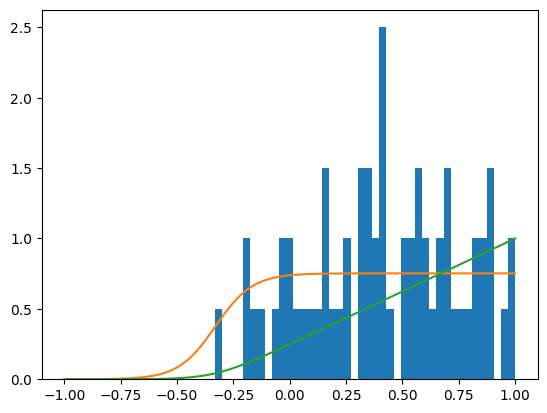

In [61]:
vals, qnts, _ = plt.hist(np.sin(tdes_df["Dec"]*np.pi/180.), range=(-1,1), bins=63, density=True)
print(vals*0.5, np.arcsin(qnts)*180./np.pi, np.sum(vals*0.5))

def sigma_f(x, width=1., offset=0.):
    b_p = (1-offset)/width
    b_m = -(1+offset)/width
    norm = 1/(width*np.log((1+np.exp(b_p))/(1+np.exp(b_m))))
    return norm/(1+np.exp(-(x-offset)/width))

def cdf_sigma_f(x, width=1., offset=0.):
    x_p = (x-offset)/width
    b_p = (1-offset)/width
    b_m = -(1+offset)/width
    denom = np.log((1+np.exp(b_p))/(1+np.exp(b_m)))
    numer = np.log((1+np.exp(x_p))/(1+np.exp(b_m)))
    return numer/denom

decs = np.linspace(-1,1,100)
plt.plot(decs, sigma_f(
    decs,
    width=width,
    offset=offset
))
plt.plot(decs, cdf_sigma_f(
    decs,
    width=width,
    offset=offset
))

In [62]:
def mykstest_lons(data):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = np.sort(data)/360.
    diffs = np.abs(s-cumul_data)
    ts = np.max(diffs)
    pval = distributions.kstwo.sf(ts, len(data))
    return pval

def cdf_lats(x, width, offset):
    x = np.sin(np.deg2rad(x))
    return cdf_sigma_f(x, width, offset)
    
def cdf_lats_unif(x):
    x = np.sin(np.deg2rad(x))
    min_sin = np.sin(-30*np.pi/180.)
    cdf = (x-min_sin) / (1-min_sin)
    return cdf

def mykstest_lats(data, width, offset):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = cdf_lats(np.sort(data), width/10., offset)
    cumul_data_unif = cdf_lats_unif(np.sort(data))
    diffs = np.abs(s-cumul_data)
    diffs_unif = np.abs(s-cumul_data_unif)
    ts = np.max(diffs)
    ts_unif = np.max(diffs_unif)
    print(ts, ts_unif)
    pval = distributions.kstwo.sf(ts, len(data))
    pval_unif = distributions.kstwo.sf(ts_unif, len(data))
    return pval, pval_unif

def mykstest_lon_lat(cat, width, offset, print_pvals=True):
    pval_lon = mykstest_lons(cat["RA"])
    pval_lat, pval_lat_unif = mykstest_lats(cat["Dec"], width, offset)
    if print_pvals:
        print(f"KS test, pval latitude: {pval_lat}, unif: {pval_lat_unif}.\t pval longitude: {pval_lon}")
    return pval_lat, pval_lon

In [63]:
width = np.sin(np.abs(min_dec)*np.pi/180.)/4.
offset = np.sin((min_dec)*np.pi/180.)
mykstest_lon_lat(tdes_df, width, np.sin(-25*np.pi/180.))

0.16918502817913042 0.20631298536156414
KS test, pval latitude: 0.04795927182742454, unif: 0.007893472761457354.	 pval longitude: 0.4060297502015845


(0.04795927182742454, 0.4060297502015845)

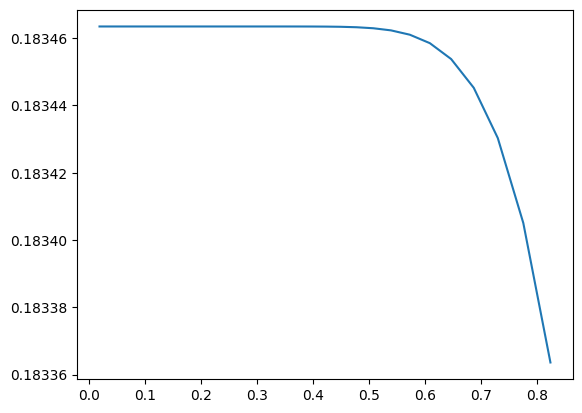

In [81]:
plt.plot(widths, pvals_lat[:,0])

In [82]:
width = np.sin(np.abs(min_dec)*np.pi/180.)/4.
offset = np.sin((min_dec)*np.pi/180.)
width/10., width*10.

(0.008232913618956606, 0.8232913618956605)

In [83]:
offset-0.2, offset+0.2

(-0.5293165447582642, -0.1293165447582642)

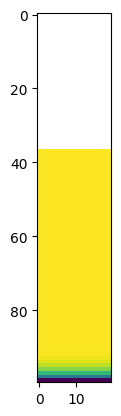

In [84]:
plt.imshow(-np.abs(pvals_lat-0.5))

In [85]:
width_index, offset_index = np.unravel_index(np.argmin(np.abs(pvals_lat-0.5)), pvals_lat.shape)

In [86]:
width_index, offset_index

(0, 0)

In [87]:
widths[width_index], offsets[offset_index]

(0.0020582284047391515, -0.3293165447582642)

In [88]:
widths[width_index], offsets[offset_index]

(0.0020582284047391515, -0.3293165447582642)

In [89]:
width = np.sin(np.abs(min_dec)*np.pi/180.)/4.
offset = np.sin((min_dec)*np.pi/180.)
width, offset

(0.08232913618956605, -0.3293165447582642)

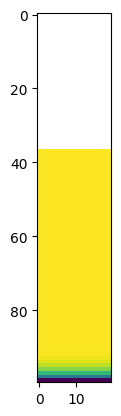

In [90]:
plt.imshow(pvals_lat)

In [91]:
np.max(pvals_lat)

nan

In [92]:
np.argmin(np.abs(pvals_lat-0.5))

0

In [93]:
np.min(np.abs(pvals_lat-0.5))

nan

In [94]:
qnts[1]-qnts[0]

0.031746031746031744

In [95]:
qnts

array([-1.        , -0.96825397, -0.93650794, -0.9047619 , -0.87301587,
       -0.84126984, -0.80952381, -0.77777778, -0.74603175, -0.71428571,
       -0.68253968, -0.65079365, -0.61904762, -0.58730159, -0.55555556,
       -0.52380952, -0.49206349, -0.46031746, -0.42857143, -0.3968254 ,
       -0.36507937, -0.33333333, -0.3015873 , -0.26984127, -0.23809524,
       -0.20634921, -0.17460317, -0.14285714, -0.11111111, -0.07936508,
       -0.04761905, -0.01587302,  0.01587302,  0.04761905,  0.07936508,
        0.11111111,  0.14285714,  0.17460317,  0.20634921,  0.23809524,
        0.26984127,  0.3015873 ,  0.33333333,  0.36507937,  0.3968254 ,
        0.42857143,  0.46031746,  0.49206349,  0.52380952,  0.55555556,
        0.58730159,  0.61904762,  0.65079365,  0.68253968,  0.71428571,
        0.74603175,  0.77777778,  0.80952381,  0.84126984,  0.87301587,
        0.9047619 ,  0.93650794,  0.96825397,  1.        ])

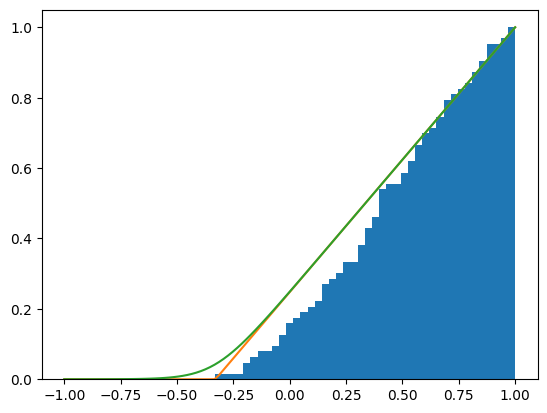

In [96]:
decs = np.linspace(-1, 1, 100)
plt.hist(np.sin(tdes_df["Dec"]*np.pi/180.), range=(-1,1), bins=63, density=True, cumulative=True)
width = np.sin(np.abs(min_dec)*np.pi/180.)/4.
plt.plot(decs, cdf_sigma_f(
    decs,
    width=widths[width_index],
    offset=offsets[offset_index]
))
plt.plot(decs, cdf_sigma_f(
    decs,
    width=width,
    offset=offset
))

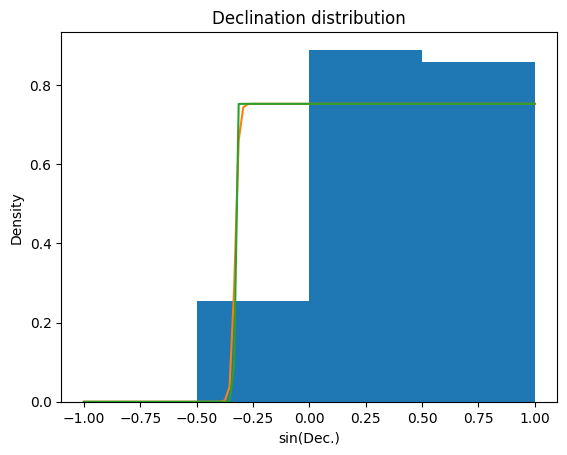

In [97]:
width = np.sin(np.abs(min_dec)*np.pi/180.)/4.
offset = np.sin((min_dec)*np.pi/180.)
plt.hist(np.sin(tdes_df["Dec"]*np.pi/180.), range=(-1,1), bins=4, density=True)
def step_f(x, start=0.):
    step = np.empty(len(x))
    step[x>=start] = 1./(1-start)
    step[x<start] = 0.
    return step
plt.plot(decs, sigma_f(
    decs,
    width=width/10.,
    offset=offset
))
plt.plot(decs, sigma_f(
    decs,
    width=widths[width_index],
    offset=offsets[offset_index]
))
#plt.plot(decs, step_f(
#    decs,
#    np.min(np.sin(tdes_df["Dec"]*np.pi/180.)) - 0.01
#))
plt.xlabel("sin(Dec.)")
plt.ylabel("Density")
plt.title("Declination distribution")
plt.savefig("logis_funct", dpi=100, bbox_inches="tight")

In [98]:
width, offset

(0.08232913618956605, -0.3293165447582642)

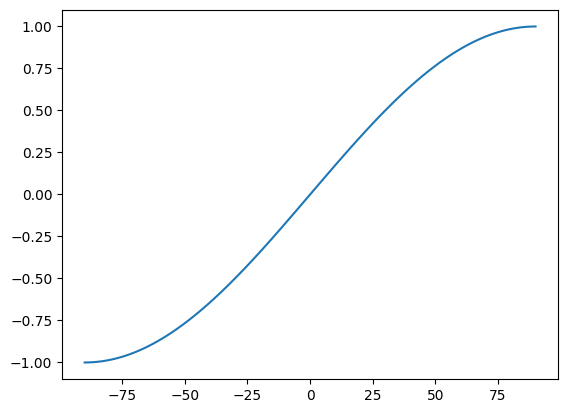

In [99]:
decs = np.linspace(-90, 90, 100)
plt.plot(decs, np.sin(decs*np.pi/180))

In [100]:
names = [
    "Name", "RAdeg", "DEdeg", "HW1mag", "HW2mag",
    "NEWS", "AllWISE", "PS1", "AllWISEcntr", "WISE",
    "AllWISEDes", "NEDLVSIndex", "NEDLVSName", "ParentSamp", "z",
    "e_z", "r_z", "SDSSdist", "SDSSclass", "TNSdist",
    "TNSobjtype1", "TNSobjtype2",
    "TNSname", "TNSdate", "milliqdist", "milliqtype", "MirongName",
    "WTPName", "RefTime", "x2W1", "npointsW1", "FmedW1",
    "x2W2", "npointsW2", "FmedW2", "FbslW1", "e_FbslW1",
    "FbslW2", "e_FbslW2", "startW1", "endW1", "endedW1",
    "startW2", "endW2", "endedW2", "strengthW1", "strengthW2",
    "varW1", "varW2", "MaxFluxW1", "e_MaxFluxW1", "MaxFluxW2",
    "e_MaxFluxW2", "FluenceW1", "e_FluenceW1", "FluenceW2", "e_FluenceW2",
    "Sep", "PeakLbol", "PeakTime", "Ebol", "Fluencebol",
]

flaires_df = pd.read_fwf(
    "../data/flaires.dat",
    names = names,
)

In [101]:
flaires_df

,Name,RAdeg,DEdeg,HW1mag,HW2mag,NEWS,AllWISE,PS1,AllWISEcntr,WISE,...,e_MaxFluxW2,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol
0,NGC 7392,342.95308,-20.60808,8.532,8.467,NaN,NaN,NaN,NaN,NaN,...,4.601000e-13,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360
1,NGC 1566,65.00175,-54.93781,6.616,6.503,NaN,NaN,NaN,NaN,NaN,...,5.790000e-13,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341
2,UGC 11487,297.35363,63.50908,10.853,10.708,NaN,NaN,NaN,NaN,NaN,...,7.700000e-14,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851
3,WISEA J161105.71+023400.3,242.77370,2.56675,12.044,11.678,NaN,NaN,NaN,NaN,NaN,...,6.704000e-14,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959
4,J003814.73-245902.2,9.56140,-24.98395,13.819,12.726,220885.0,J003814.73-245902.2,7.801010e+16,NaN,NaN,...,5.477000e-13,0.001283,7.015000e-05,0.001314,5.833000e-05,0.02,6.338000e+46,0.00,2.596000e+54,0.002569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,WISEA J055017.31+491117.9,87.57210,49.18834,13.811,13.415,NaN,NaN,1.670209e+17,8.771484e+17,WISE,...,1.363000e-14,0.000025,2.678000e-06,0.000023,1.571000e-06,0.08,8.400000e+43,0.00,NaN,NaN
819,WISE J051107.04+462247.5,77.77956,46.37986,12.928,12.479,NaN,NaN,1.636508e+17,7.851469e+17,WISE,...,2.890000e-14,0.000000,0.000000e+00,0.000000,0.000000e+00,0.17,NaN,NaN,NaN,NaN
820,WISE J211803.31+403522.8,319.51394,40.58966,13.576,13.307,NaN,NaN,1.567032e+17,3.204141e+18,WISE,...,3.449000e-14,0.000009,8.501000e-07,0.000008,6.523000e-07,0.11,NaN,NaN,NaN,NaN
821,WISEA J130726.58-162006.4,196.86046,-16.33539,11.922,11.738,NaN,NaN,NaN,NaN,NaN,...,6.357000e-14,0.000000,0.000000e+00,0.000000,0.000000e+00,0.08,NaN,NaN,NaN,NaN


In [102]:
flaires_df["PeakTime"] + flaires_df["RefTime"]

0      57169.94
1      58323.83
2      57921.21
3      58179.30
4      58288.83
         ...   
818    55460.02
819         NaN
820         NaN
821         NaN
822    58884.34
Length: 823, dtype: float64

In [103]:
flaires_df.keys(), len(flaires_df.keys())

(Index(['Name', 'RAdeg', 'DEdeg', 'HW1mag', 'HW2mag', 'NEWS', 'AllWISE', 'PS1',
        'AllWISEcntr', 'WISE', 'AllWISEDes', 'NEDLVSIndex', 'NEDLVSName',
        'ParentSamp', 'z', 'e_z', 'r_z', 'SDSSdist', 'SDSSclass', 'TNSdist',
        'TNSobjtype1', 'TNSobjtype2', 'TNSname', 'TNSdate', 'milliqdist',
        'milliqtype', 'MirongName', 'WTPName', 'RefTime', 'x2W1', 'npointsW1',
        'FmedW1', 'x2W2', 'npointsW2', 'FmedW2', 'FbslW1', 'e_FbslW1', 'FbslW2',
        'e_FbslW2', 'startW1', 'endW1', 'endedW1', 'startW2', 'endW2',
        'endedW2', 'strengthW1', 'strengthW2', 'varW1', 'varW2', 'MaxFluxW1',
        'e_MaxFluxW1', 'MaxFluxW2', 'e_MaxFluxW2', 'FluenceW1', 'e_FluenceW1',
        'FluenceW2', 'e_FluenceW2', 'Sep', 'PeakLbol', 'PeakTime', 'Ebol',
        'Fluencebol'],
       dtype='object'),
 62)

In [104]:
set(flaires_df["milliqtype"])

{'A',
 'ARX',
 'AX',
 'BR',
 'BRX',
 'KRX',
 'N',
 'Q',
 'QR',
 'QRX',
 'QX',
 'R',
 'X',
 nan,
 'q',
 'qR',
 'qX'}

In [105]:
possible_types = [
    'A', 'ARX', 'AX', 'BR', 'BRX',
    'KRX', 'N', 'Q', 'QR', 'QRX',
    'QX', 'R', 'X', 'q', 'qR', 'qX'
]

In [106]:
len(flaires_df)

823

In [107]:
fluencemask = ~np.isnan(flaires_df['Fluencebol'])
syncrojetmask = ~(
    (flaires_df["milliqtype"]=="BR")  |
    (flaires_df["milliqtype"]=="BRX") |
    (flaires_df["milliqtype"]=="KRX") |
    (flaires_df["milliqtype"]=="QR")  |
    (flaires_df["milliqtype"]=="QRX") |
    (flaires_df["milliqtype"]=="Q")   |
    (flaires_df["milliqtype"]=="QX")  |
    (flaires_df["milliqtype"]=="qRX") |
    (flaires_df["milliqtype"]=="q")   | 
    (flaires_df["milliqtype"]=="qR")
)
tdemask = np.array(
    fluencemask & syncrojetmask,
)

In [108]:
flaires_df[tdemask]

,Name,RAdeg,DEdeg,HW1mag,HW2mag,NEWS,AllWISE,PS1,AllWISEcntr,WISE,...,e_MaxFluxW2,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol
0,NGC 7392,342.95308,-20.60808,8.532,8.467,NaN,NaN,NaN,NaN,NaN,...,4.601000e-13,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360
1,NGC 1566,65.00175,-54.93781,6.616,6.503,NaN,NaN,NaN,NaN,NaN,...,5.790000e-13,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341
2,UGC 11487,297.35363,63.50908,10.853,10.708,NaN,NaN,NaN,NaN,NaN,...,7.700000e-14,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851
3,WISEA J161105.71+023400.3,242.77370,2.56675,12.044,11.678,NaN,NaN,NaN,NaN,NaN,...,6.704000e-14,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959
5,WISEA J154843.06+220812.6,237.17944,22.13686,13.625,13.570,NaN,NaN,1.345624e+17,2.378123e+18,WISE,...,4.542000e-14,0.000762,4.777000e-06,0.000775,4.688000e-06,0.04,6.430000e+43,99.37,5.780000e+51,0.002401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561,J185546.08+381941.1,283.94201,38.32809,15.455,15.322,443829.0,J185546.08+381941.1,1.539928e+17,2.842138e+18,WISE,...,1.092000e-14,0.000002,3.388000e-07,0.000002,3.662000e-07,0.08,5.703000e+42,0.00,6.996000e+49,0.000003
562,J175849.74+585957.2,269.70731,58.99917,15.779,15.275,14472566.0,J175849.74+585957.2,1.787927e+17,NaN,NaN,...,7.314000e-15,0.000002,2.061000e-07,0.000002,2.537000e-07,0.05,5.931000e+43,-65.55,5.881000e+50,0.000003
563,J175918.34+482759.3,269.82631,48.46656,15.014,14.404,25813160.0,J175918.34+482759.3,1.661627e+17,NaN,NaN,...,1.279000e-14,0.000002,2.292000e-07,0.000003,4.599000e-07,0.15,7.421000e+43,0.00,6.969000e+50,0.000003
564,J103622.74+750941.6,159.09481,75.16158,15.222,14.859,842494.0,J103622.74+750941.6,1.981916e+17,NaN,NaN,...,1.188000e-14,0.000002,1.275000e-07,0.000002,2.621000e-07,0.09,4.970000e+43,-0.00,4.088000e+50,0.000003


In [109]:
set(flaires_df[tdemask]["milliqtype"])

{'A', 'ARX', 'AX', 'N', 'X', nan}

In [110]:
len(flaires_df[tdemask])

528

In [111]:
newtdes_df = flaires_df[tdemask]
len(newtdes_df)

528

(0.0, 360.0)

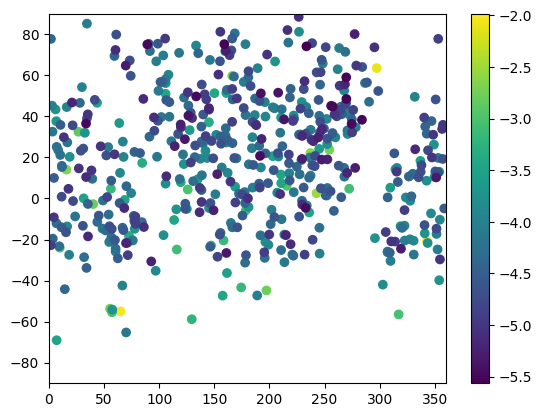

In [112]:
plt.scatter(newtdes_df["RAdeg"], newtdes_df["DEdeg"], c=np.log10(newtdes_df["Fluencebol"]))
plt.colorbar()
plt.ylim(-90,90)
plt.xlim(0,360)

In [113]:
from astropy import units as u
from astropy.coordinates import SkyCoord

def to_gal(ra, dec):
    c_icrs = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
    gal_coords = c_icrs.galactic
    return gal_coords.l.deg, gal_coords.b.deg

(0.0, 360.0)

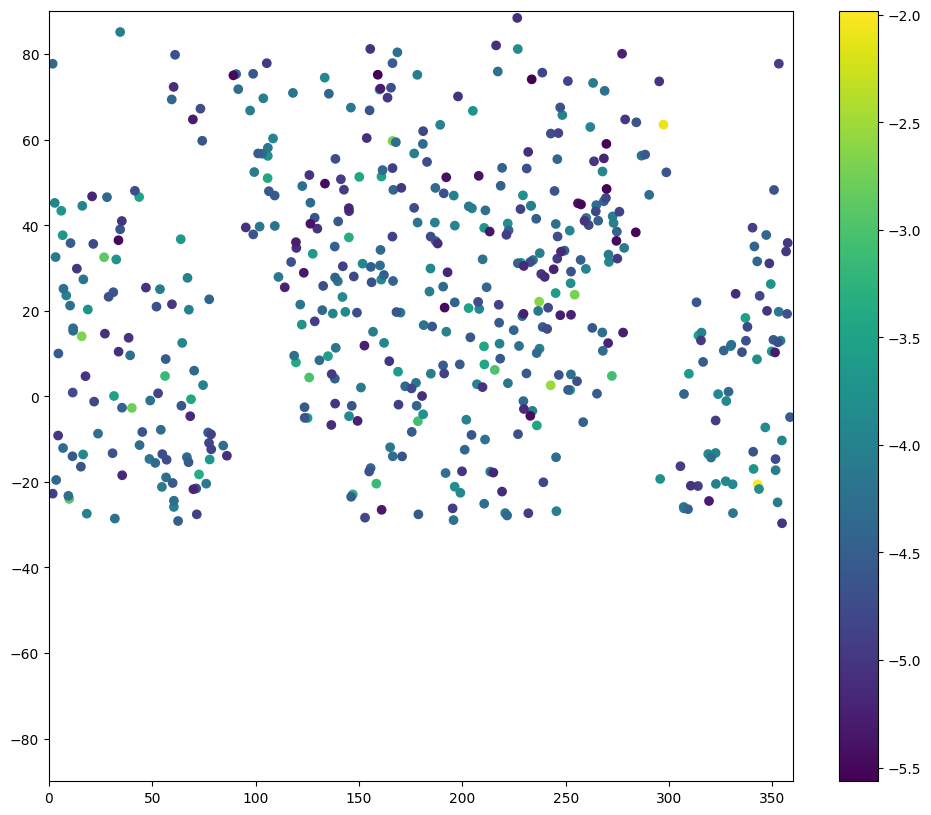

In [114]:
plt.figure(figsize=(12,10))
decmask = newtdes_df["DEdeg"]>=-30.
gal_coords = np.array([
    to_gal(ra, dec) for ra, dec in zip(newtdes_df["RAdeg"], newtdes_df["DEdeg"])
])
galmask = np.abs(gal_coords[:,1])>=10
plt.scatter(
    newtdes_df["RAdeg"][np.logical_and(decmask,galmask)],
    newtdes_df["DEdeg"][np.logical_and(decmask,galmask)],
    c=np.log10(newtdes_df["Fluencebol"][np.logical_and(decmask,galmask)])
)
plt.colorbar()
plt.ylim(-90,90)
plt.xlim(0,360)

In [115]:
ult_df = newtdes_df[np.logical_and(decmask,galmask)]

In [116]:
def mykstest_lons(data):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = np.sort(data)/360.
    diffs = np.abs(s-cumul_data)
    ts = np.max(diffs)
    pval = distributions.kstwo.sf(ts, len(data))
    return pval

def cdf_lats(x, width, offset):
    x = np.sin(np.deg2rad(x))
    return cdf_sigma_f(x, width, offset)
    
def cdf_lats_unif(x):
    x = np.sin(np.deg2rad(x))
    min_sin = np.sin(-30*np.pi/180.)
    cdf = (x-min_sin) / (1-min_sin)
    return cdf

def mykstest_lats(data, width, offset):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = cdf_lats(np.sort(data), width/10., offset)
    cumul_data_unif = cdf_lats_unif(np.sort(data))
    diffs = np.abs(s-cumul_data)
    diffs_unif = np.abs(s-cumul_data_unif)
    ts = np.max(diffs)
    ts_unif = np.max(diffs_unif)
    print(ts, ts_unif)
    pval = distributions.kstwo.sf(ts, len(data))
    pval_unif = distributions.kstwo.sf(ts_unif, len(data))
    return pval, pval_unif

def mykstest_lon_lat(cat, width, offset, print_pvals=True):
    pval_lon = mykstest_lons(cat["RA"])
    pval_lat, pval_lat_unif = mykstest_lats(cat["Dec"], width, offset)
    if print_pvals:
        print(f"KS test, pval latitude: {pval_lat}, unif: {pval_lat_unif}.\t pval longitude: {pval_lon}")
    return pval_lat, pval_lon

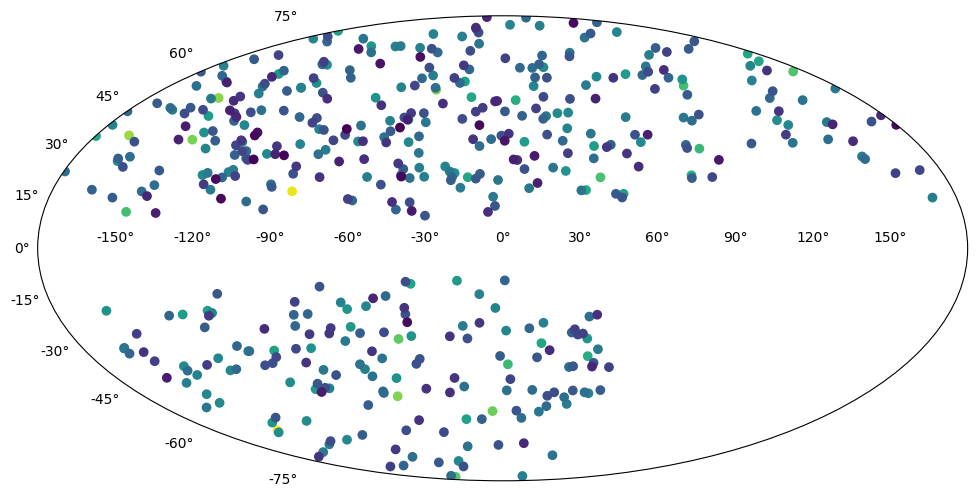

In [117]:
plt.figure(figsize=(12,10))
plt.subplot(111, projection='mollweide')
gal_coords = np.array([
    to_gal(ra, dec) for ra, dec in zip(ult_df["RAdeg"], ult_df["DEdeg"])
])
plt.scatter(
    np.deg2rad(gal_coords[:,0] - 180.),
    np.deg2rad(gal_coords[:,1]),
    c=np.log10(ult_df["Fluencebol"])
)
#plt.colorbar()

Found 528 sources in total
Found 528 sources in total
528


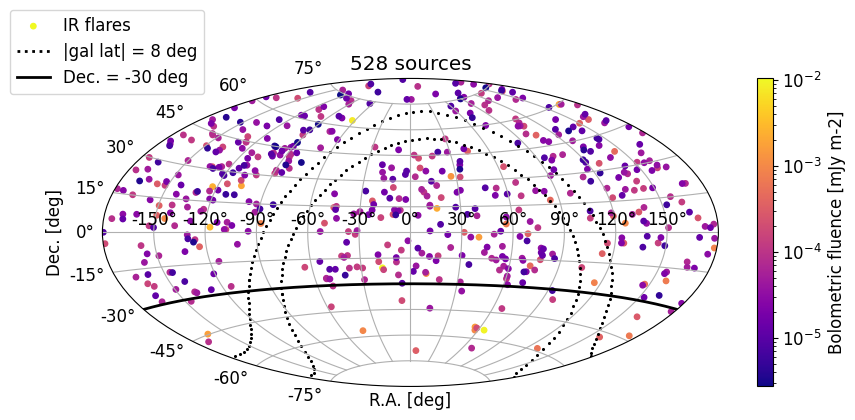

In [118]:
acflares_obj = FlairesCatalogue()
weighter = FluencebolHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.parse_data()
print(len(acflares["ra_deg"]))
plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=15,
    label="IR flares",
    c=weighter.weight_catalogue(acflares, 0., ignore_times=True),
    norm="log",
    cmap="plasma",
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="black", linestyle='dotted', label="|gal lat| = 8 deg", linewidth=2)
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=1.5, c="black")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=1.5, c="black")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-30.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -30 deg", linewidth=2)
plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Bolometric fluence [mJy m-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title(f"{len(ras_mollweide)} sources", fontsize="x-large")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")
plt.savefig("../data/flaires_data", dpi=150, bbox_inches="tight")
plt.savefig("../data/flaires_data.pdf", dpi=150, bbox_inches="tight")

Found 528 sources in total
528


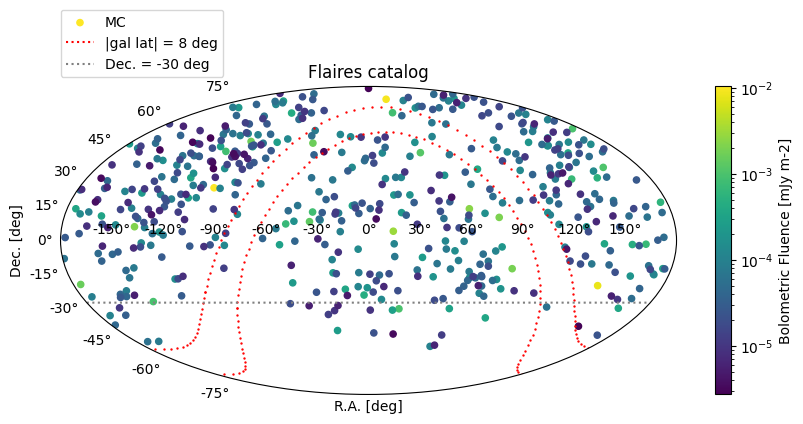

In [119]:
acflares_obj = FlairesCatalogue()
weighter = FluencebolHypothesis(HealpixNeutrinoAlertCatalogue())
acflares = acflares_obj.scramble()
print(len(acflares["ra_deg"]))
plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='mollweide')
ras_mollweide = np.empty(len(acflares))
ras_mollweide[acflares["ra_deg"]<=180.] = acflares["ra_deg"][acflares["ra_deg"]<=180.]
ras_mollweide[acflares["ra_deg"]>180.] = acflares["ra_deg"][acflares["ra_deg"]>180.] - 360.

im = plt.scatter(
    ras_mollweide*np.pi/180.,
    acflares["dec_deg"]*np.pi/180.,
    s=20,
    label="MC",
    c=weighter.weight_catalogue(acflares, 0., ignore_times=True),
    #c=acflares["Fluencebol"],
    norm="log",
)

gp_lons = np.linspace(0., 360., 100)
gp_cut = 8.
gal_p = SkyCoord(
    l = gp_lons*u.deg, b = gp_cut*u.deg, frame='galactic'
)
gal_m = SkyCoord(
    l = gp_lons*u.deg, b = -gp_cut*u.deg, frame='galactic'
)
ra_vals_p = gal_p.icrs.ra.rad
dec_vals_p = gal_p.icrs.dec.rad
ra_vals_mollw_p = np.empty(len(ra_vals_p))
ra_vals_mollw_p[ra_vals_p<=np.pi] = ra_vals_p[ra_vals_p<=np.pi]
ra_vals_mollw_p[ra_vals_p>np.pi] = ra_vals_p[ra_vals_p>np.pi] - 2*np.pi
ra_vals_m = gal_m.icrs.ra.rad
dec_vals_m = gal_m.icrs.dec.rad
ra_vals_mollw_m = np.empty(len(ra_vals_m))
ra_vals_mollw_m[ra_vals_m<=np.pi] = ra_vals_m[ra_vals_m<=np.pi]
ra_vals_mollw_m[ra_vals_m>np.pi] = ra_vals_m[ra_vals_m>np.pi] - 2*np.pi
plt.plot(1,1, color="red", linestyle="dotted", label="|gal lat| = 8 deg")
plt.scatter(ra_vals_mollw_p, dec_vals_p, s=0.5, c="r")
plt.scatter(ra_vals_mollw_m, dec_vals_m, s=0.5, c="r")
ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-30.*np.pi/180.)
plt.plot(ras_bord, des_bord, linestyle = "dotted", color="grey", label="Dec. = -30 deg")
plt.legend(loc=(0, 1.03))
plt.gcf().colorbar(
    im,
    label="Bolometric Fluence [mJy m-2]",
)

plt.title("Flaires catalog")
plt.xlabel("R.A. [deg]")
plt.ylabel("Dec. [deg]")
plt.savefig("../data/flaires_data_MC", dpi=150, bbox_inches="tight")

In [120]:
acflares

,Source_Name,ra_rad,dec_rad,ra_deg,dec_deg,t-peak,HW1mag,HW2mag,NEWS,AllWISE,...,e_MaxFluxW2,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol
0,NGC 7392,4.606269,0.440871,263.919761,25.260054,57169.94,8.532,8.467,NaN,NaN,...,4.601000e-13,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360
1,NGC 1566,0.449375,1.331901,25.747292,76.312307,58323.83,6.616,6.503,NaN,NaN,...,5.790000e-13,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341
2,UGC 11487,2.444610,-0.377133,140.065857,-21.608149,57921.21,10.853,10.708,NaN,NaN,...,7.700000e-14,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851
3,WISEA J161105.71+023400.3,0.253263,0.076348,14.510896,4.374420,58179.30,12.044,11.678,NaN,NaN,...,6.704000e-14,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959
4,WISEA J154843.06+220812.6,1.050914,0.263066,60.212941,15.072576,59250.29,13.625,13.570,NaN,NaN,...,4.542000e-14,0.000762,4.777000e-06,0.000775,4.688000e-06,0.04,6.430000e+43,99.37,5.780000e+51,0.002401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,J185546.08+381941.1,3.954552,0.852383,226.579143,48.837950,57855.26,15.455,15.322,443829.0,J185546.08+381941.1,...,1.092000e-14,0.000002,3.388000e-07,0.000002,3.662000e-07,0.08,5.703000e+42,0.00,6.996000e+49,0.000003
524,J175849.74+585957.2,4.125918,0.893526,236.397663,51.195279,58943.20,15.779,15.275,14472566.0,J175849.74+585957.2,...,7.314000e-15,0.000002,2.061000e-07,0.000002,2.537000e-07,0.05,5.931000e+43,-65.55,5.881000e+50,0.000003
525,J175918.34+482759.3,6.282705,1.512532,359.972507,86.661708,58928.85,15.014,14.404,25813160.0,J175918.34+482759.3,...,1.279000e-14,0.000002,2.292000e-07,0.000003,4.599000e-07,0.15,7.421000e+43,0.00,6.969000e+50,0.000003
526,J103622.74+750941.6,2.578542,-0.735370,147.739596,-42.133610,58047.12,15.222,14.859,842494.0,J103622.74+750941.6,...,1.188000e-14,0.000002,1.275000e-07,0.000002,2.621000e-07,0.09,4.970000e+43,-0.00,4.088000e+50,0.000003


In [121]:
from scipy.stats import uniform

def generate_dec(cut_dec=-30, size=100):
    rnd_dec = np.rad2deg(
        np.arcsin(
            uniform.rvs(size=size)*(
                1. - np.sin(cut_dec*np.pi/180.)
            ) + np.sin(cut_dec*np.pi/180.)
        )
    )
    return rnd_dec

def generate_ra(size=100):
    return uniform.rvs(size=size)*360.

def generate_ra_dec(cut_dec=-30, size=100):
    rnd_dec = generate_dec(cut_dec, size)
    rnd_ra  = generate_ra(size)
    return rnd_ra, rnd_dec

def generate_MC(cut_dec=-30, cut_GP=10, size=100):
    rnd_ra, rnd_dec = generate_ra_dec(cut_dec, size)
    for index, (r, d) in enumerate(zip(rnd_ra, rnd_dec)):
        lon, lat = to_gal(r, d)
        while np.abs(lat) < 10:
            r, d = generate_ra_dec(cut_dec, size=1)
            lon, lat = to_gal(r, d)
        rnd_ra[index] = r
        rnd_dec[index] = d
    return rnd_ra, rnd_dec

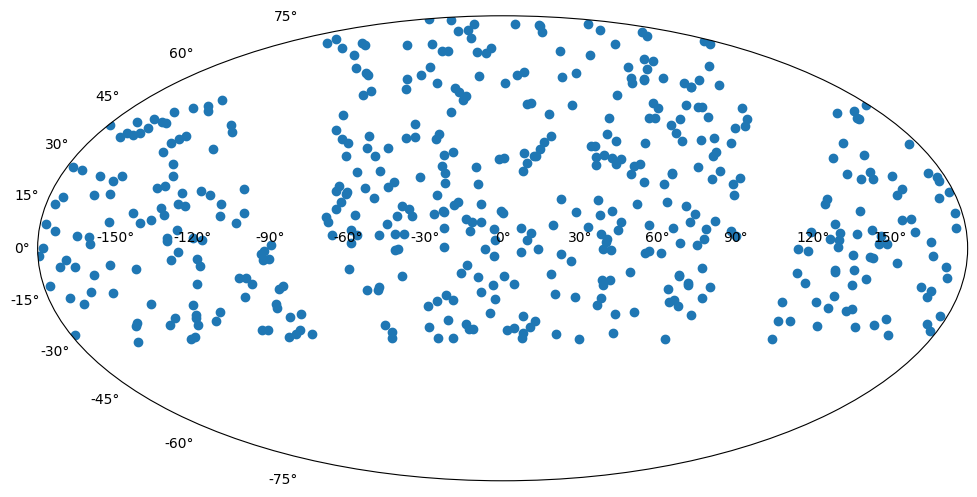

In [122]:
plt.figure(figsize=(12,10))
plt.subplot(111, projection='mollweide')
ras, decs = generate_MC(size=len(ult_df))
plt.scatter(
    np.deg2rad(ras - 180.),
    np.deg2rad(decs),
)

In [123]:
all_vals_ra = []
all_vals_de = []
for i in range(200):
    if i%10 == 0:
        print(i)
    ras, decs = generate_MC(size=len(ult_df))
    vals_ra, quantiles_ra, _  = plt.hist(
        ras, range=(0,360.), bins=20,
        #density=True
    )
    vals_de, quantiles_de, _  = plt.hist(
        np.sin(decs*np.pi/180.), range=(-1.,1.), bins=20, #density=True
    )
    xs_ra = (quantiles_ra[:-1] + quantiles_ra[1:])/2.
    xs_de = (quantiles_de[:-1] + quantiles_de[1:])/2.
    plt.close()
    all_vals_ra.append(vals_ra)
    all_vals_de.append(vals_de)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190


In [124]:
all_vals_ra = np.array(all_vals_ra)
all_vals_de = np.array(all_vals_de)

In [125]:
means_ra = np.array([np.mean(all_vals_ra[:,j]) for j in range(len(xs_ra))])
means_de = np.array([np.mean(all_vals_de[:,j]) for j in range(len(xs_de))])
stds_ra = np.array([np.std(all_vals_ra[:,j]) for j in range(len(xs_ra))])
stds_de = np.array([np.std(all_vals_de[:,j]) for j in range(len(xs_de))])

Chi2 result from comparison with weighted expetations: 28.581653102409224, pval: 0.09632952374526538


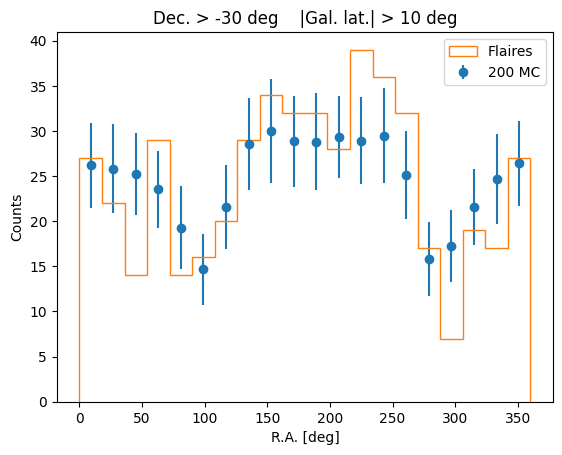

In [126]:
from scipy import stats
plt.errorbar(xs_ra, means_ra, stds_ra, marker="o", linestyle="", label="200 MC")
real_vals, _, _, = plt.hist(
    ult_df["RAdeg"], bins=20, range=(0.,360.), histtype="step", label="Flaires",
    #density=True, weights=ult_df["Fluencebol"]
)
chi_sq = np.sum(((real_vals - means_ra)/stds_ra)**2)
pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(real_vals))
print(
    "Chi2 result from comparison with weighted expetations:"
    f" {chi_sq}, pval: {pval_chisq}"
)
plt.xlabel("R.A. [deg]")
plt.ylabel("Counts")
plt.legend()
plt.title("Dec. > -30 deg    |Gal. lat.| > 10 deg")
plt.savefig("Flaires_uniform_ra", dpi=200, bbox_inches="tight")

Chi2 result from comparison with weighted expetations: 36.975125337117156, pval: 0.011782653410637556


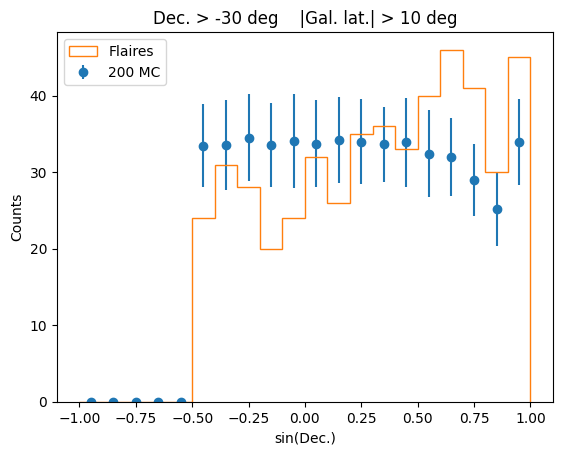

In [127]:
plt.errorbar(
    xs_de,
    means_de,
    stds_de,
    linestyle="",
    marker="o",
    label="200 MC"
)
real_vals, _, _, = plt.hist(
    np.sin(ult_df["DEdeg"]*np.pi/180.),
    #weights=ult_df["Fluencebol"],
    #density=True,
    bins=20,
    range=(-1.,1.),
    histtype="step",
    label="Flaires"
)
chi_sq = np.sum(((real_vals[real_vals!=0.] - means_de[real_vals!=0.])/stds_de[real_vals!=0.])**2)
pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(real_vals))
print(
    "Chi2 result from comparison with weighted expetations:"
    f" {chi_sq}, pval: {pval_chisq}"
)
plt.xlabel("sin(Dec.)")
plt.ylabel("Counts")
plt.legend()
plt.title("Dec. > -30 deg    |Gal. lat.| > 10 deg")
plt.savefig("Flaires_uniform_dec", dpi=200, bbox_inches="tight")

In [128]:
np.sum([(
    milltyp=="qR" or milltyp=="Q" or milltyp=="B" or milltyp=="k" or milltyp=="q"
) for milltyp in flaires_df["milliqtype"][
    ~np.isnan(flaires_df['Fluencebol'])
]])

23

In [129]:
for a in flaires_df["milliqtype"]:
    if a == "q" or a == "qR" or a == "qX":
        print(a)

q
q
q
q
q
q
q
q
q
q
qR
qR
q
q
q
q
q
qR
q
q
q
q
qR
q
q
q
qX
q
q
q
q
q
q
qR
q
q
q
q
q
q
q
qX


In [130]:
set(flaires_df["TNSobjtype1"])

{'AGN', 'CV', 'SLSN-', 'SN', 'SN II', 'TDE', nan}

In [131]:
set(flaires_df["TNSobjtype2"])

{'AT', 'SN', nan}

In [132]:
set(flaires_df["SDSSclass"])

{'AGN (not liner)',
 'composite',
 'low S/N liner',
 'low S/N star-forming',
 nan,
 'star_forming'}